# K-Moda — EDA para Marketing Mix Modeling (MMM)

## Contexto de negocio

K-Moda opera en 10 ciudades españolas (Madrid, Barcelona, Valencia, Sevilla, Bilbao, Zaragoza, Málaga, Murcia, Palma, A Coruña) con presencia tanto física (tienda) como digital (online + click & collect).  
El equipo de marketing invierte en 8 canales de medios: *Paid Search, Social Paid, Display, Video Online, Email CRM, Exterior, Radio Local y Prensa*.

**Pregunta de negocio clave:** ¿Qué canales tienen mayor impacto en las ventas y con qué retardo temporal?

---

## Fuentes de datos disponibles

| Tabla | Descripción | Granularidad |
|---|---|---|
| `ventas_lineas.csv` | Líneas de pedido con venta neta | Línea × día |
| `pedidos.csv` | Cabecera de pedido | Pedido × día |
| `inversion_medios_semanal.csv` | Inversión por canal y ciudad | Semana × ciudad × canal |
| `trafico_tienda_web_diario.csv` | Sesiones web y visitas tienda | Día × ciudad |
| `calendario_ciudad.csv` | Variables de calendario y clima | Día × ciudad |
| `clientes.csv` | Perfil de clientes | Cliente |
| `productos.csv` | Catálogo de productos | SKU |

---

## Estructura del notebook

1. Librerías y configuración  
2. Carga de datos  
3. Procesamiento inicial y calidad  
4. Construcción de la variable objetivo (ventas)  
5. Análisis univariado  
6. Análisis temporal  
7. Análisis de variables explicativas  
8. Dataset maestro semanal  
9. Correlaciones iniciales  
10. Análisis avanzado MMM (lag, adstock, saturación)  
11. Conclusiones y próximos pasos  

---
## 1. Librerías y configuración

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.optimize import curve_fit

# ── Estilo global ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('tab10')
PALETTE_CANALES = sns.color_palette('tab10', n_colors=8)

# ── Rutas ─────────────────────────────────────────────────────────────────────
RAW   = Path('../data/raw')
PROC  = Path('../data/processed')
PROC.mkdir(parents=True, exist_ok=True)

# ── Parámetro de muestreo para tablas grandes (None = carga completa) ─────────
# Ajusta SAMPLE_ROWS a None para procesar los 8M de filas en producción.
# Con 500_000 el notebook se ejecuta en ~1 min en un portátil estándar.
SAMPLE_ROWS = 500_000

print('Librerías cargadas correctamente.')
print(f'Directorio de datos: {RAW.resolve()}')
print(f'Modo: {"MUESTRA " + str(SAMPLE_ROWS) + " filas" if SAMPLE_ROWS else "CARGA COMPLETA"}')

Librerías cargadas correctamente.
Directorio de datos: C:\Users\victo\OneDrive\Escritorio\Caso_2_IA\data\raw
Modo: MUESTRA 500000 filas


---
## 2. Carga de datos

Cargamos primero las **tablas pequeñas** completas y luego la tabla de ventas con gestión de memoria.

> **Nota técnica:** `ventas_lineas.csv` y `pedidos.csv` tienen ~8 M filas cada una. Para el EDA usamos un sample aleatorio estratificado; para el dataset final de modelado usaremos la carga completa con chunking.

In [2]:
# ── Tablas de tamaño manejable ────────────────────────────────────────────────
medios    = pd.read_csv(RAW / 'inversion_medios_semanal.csv',   parse_dates=['semana_inicio', 'semana_fin'])
trafico   = pd.read_csv(RAW / 'trafico_tienda_web_diario.csv',  parse_dates=['fecha'])
calendario= pd.read_csv(RAW / 'calendario_ciudad.csv',          parse_dates=['fecha'])
clientes  = pd.read_csv(RAW / 'clientes.csv')
productos = pd.read_csv(RAW / 'productos.csv')

for nombre, df in [('medios', medios), ('trafico', trafico),
                   ('calendario', calendario), ('clientes', clientes), ('productos', productos)]:
    print(f'{nombre:<15} {df.shape[0]:>8,} filas  |  {df.shape[1]:>3} columnas')

medios            20,880 filas  |    9 columnas
trafico           18,270 filas  |   18 columnas
calendario        18,270 filas  |   18 columnas
clientes         600,000 filas  |    9 columnas
productos            510 filas  |    9 columnas


In [3]:
# ── Tabla grande: ventas_lineas ───────────────────────────────────────────────
# Usamos nrows para exploración; la agregación completa se hace en la Sección 4.
ventas_raw = pd.read_csv(
    RAW / 'ventas_lineas.csv',
    parse_dates=['fecha_venta'],
    nrows=SAMPLE_ROWS,
    dtype={'id_linea': 'str', 'id_pedido': 'str', 'id_cliente': 'str',
           'ciudad': 'category', 'canal_venta': 'category',
           'categoria': 'category', 'subcategoria': 'category'}
)
print(f'ventas_raw     {ventas_raw.shape[0]:>8,} filas  |  {ventas_raw.shape[1]:>3} columnas')
ventas_raw.head(3)

ventas_raw      500,000 filas  |   15 columnas


,id_linea,id_pedido,fecha_venta,id_cliente,ciudad,canal_venta,sku,categoria,subcategoria,articulo,pvp_bruto_eur,descuento_pct,venta_neta_sin_iva_eur,coste_produccion_eur,cantidad_unidades
0,L0,P0,2022-05-10,C004267_8,Bilbao,Online,SKU_GENERIC,Ropa,General,Prenda Estándar,138.15,10,124.34,52.85,3
1,L1,P1,2024-10-23,C023519_19,Sevilla,Offline,SKU_GENERIC,Ropa,General,Prenda Estándar,164.36,0,164.36,65.47,3
2,L2,P2,2023-12-19,C000115_7,Bilbao,Online,SKU_GENERIC,Ropa,General,Prenda Estándar,56.16,0,56.16,23.49,1


In [4]:
# ── Vista rápida de cada tabla ────────────────────────────────────────────────
print('=== ventas_lineas (muestra) ===')
print(ventas_raw.info())
print('\n=== inversion_medios ===')
print(medios.info())
print('\n=== trafico_web ===')
print(trafico.info())

=== ventas_lineas (muestra) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   id_linea                500000 non-null  object        
 1   id_pedido               500000 non-null  object        
 2   fecha_venta             500000 non-null  datetime64[ns]
 3   id_cliente              500000 non-null  object        
 4   ciudad                  500000 non-null  category      
 5   canal_venta             500000 non-null  category      
 6   sku                     500000 non-null  object        
 7   categoria               500000 non-null  category      
 8   subcategoria            500000 non-null  category      
 9   articulo                500000 non-null  object        
 10  pvp_bruto_eur           500000 non-null  float64       
 11  descuento_pct           500000 non-null  int64         
 12

In [5]:
# ── Estadísticos descriptivos básicos ────────────────────────────────────────
ventas_raw[['pvp_bruto_eur', 'descuento_pct', 'venta_neta_sin_iva_eur',
            'coste_produccion_eur', 'cantidad_unidades']].describe().round(2)

,pvp_bruto_eur,descuento_pct,venta_neta_sin_iva_eur,coste_produccion_eur,cantidad_unidades
count,500000.00,500000.00,500000.00,500000.00,500000.00
mean,99.87,4.00,95.87,37.45,2.50
std,54.71,6.64,53.07,21.10,1.12
min,20.00,0.00,16.00,6.01,1.00
25%,53.34,0.00,51.08,19.82,1.00
50%,92.15,0.00,88.01,34.04,2.00
75%,136.77,10.00,130.58,50.83,3.00
max,239.99,20.00,239.99,107.77,4.00


---
## 3. Procesamiento inicial y calidad de datos

Antes de construir cualquier análisis, verificamos **nulos, duplicados y coherencia temporal**.  
Un dato mal procesado en esta etapa contamina todo el modelo posterior.

In [6]:
def resumen_calidad(df, nombre):
    """Tabla de nulos, tipos y valores únicos por columna."""
    r = pd.DataFrame({
        'tipo': df.dtypes,
        'nulos': df.isnull().sum(),
        'pct_nulo': (df.isnull().mean() * 100).round(2),
        'n_unicos': df.nunique(),
    })
    r = r[r['nulos'] > 0] if r['nulos'].sum() > 0 else r
    print(f'\n── {nombre} ──  duplicados exactos: {df.duplicated().sum():,}')
    return r

display(resumen_calidad(ventas_raw, 'ventas_lineas'))
display(resumen_calidad(medios, 'inversion_medios'))
display(resumen_calidad(trafico, 'trafico_web'))
display(resumen_calidad(calendario, 'calendario'))


── ventas_lineas ──  duplicados exactos: 0


,tipo,nulos,pct_nulo,n_unicos
id_linea,object,0,0.0,500000
id_pedido,object,0,0.0,500000
fecha_venta,datetime64[ns],0,0.0,1827
id_cliente,object,0,0.0,339179
ciudad,category,0,0.0,5
canal_venta,category,0,0.0,2
sku,object,0,0.0,1
categoria,category,0,0.0,1
subcategoria,category,0,0.0,1
articulo,object,0,0.0,1



── inversion_medios ──  duplicados exactos: 0


,tipo,nulos,pct_nulo,n_unicos
semana_inicio,datetime64[ns],0,0.0,261
semana_fin,datetime64[ns],0,0.0,261
anio,int64,0,0.0,6
semana_iso,int64,0,0.0,53
ciudad,object,0,0.0,10
canal_medio,object,0,0.0,8
tipo_medio,object,0,0.0,2
inversion_eur,float64,0,0.0,20488
objetivo_principal,object,0,0.0,6



── trafico_web ──  duplicados exactos: 0


,tipo,nulos,pct_nulo,n_unicos
fecha,datetime64[ns],0,0.0,1827
ciudad,object,0,0.0,10
visitas_tienda,int64,0,0.0,106
pedidos_tienda,float64,0,0.0,29
pedidos_click_collect,float64,0,0.0,16
tasa_conversion_tienda_pct,float64,0,0.0,1194
sesiones_web,int64,0,0.0,715
pedidos_online,float64,0,0.0,26
tasa_conversion_web_pct,float64,0,0.0,518
rebajas_flag,int64,0,0.0,2



── calendario ──  duplicados exactos: 0


,tipo,nulos,pct_nulo,n_unicos
fecha,datetime64[ns],0,0.0,1827
ciudad,object,0,0.0,10
anio,int64,0,0.0,5
mes,int64,0,0.0,12
dia_semana_num,int64,0,0.0,7
dia_semana,object,0,0.0,7
fin_de_semana,int64,0,0.0,2
payday_flag,int64,0,0.0,2
rebajas_flag,int64,0,0.0,2
black_friday_flag,int64,0,0.0,2


In [7]:
# ── Cobertura temporal de cada tabla ─────────────────────────────────────────
coberturas = {
    'ventas_lineas (muestra)': (ventas_raw['fecha_venta'].min(), ventas_raw['fecha_venta'].max()),
    'inversion_medios':        (medios['semana_inicio'].min(),   medios['semana_fin'].max()),
    'trafico_web':             (trafico['fecha'].min(),          trafico['fecha'].max()),
    'calendario':              (calendario['fecha'].min(),        calendario['fecha'].max()),
}

print(f'{"Tabla":<30} {"Inicio":<15} {"Fin":<15}')
print('-' * 60)
for t, (ini, fin) in coberturas.items():
    print(f'{t:<30} {str(ini)[:10]:<15} {str(fin)[:10]:<15}')

Tabla                          Inicio          Fin            
------------------------------------------------------------
ventas_lineas (muestra)        2020-01-01      2024-12-31     
inversion_medios               2020-01-06      2025-01-05     
trafico_web                    2020-01-01      2024-12-31     
calendario                     2020-01-01      2024-12-31     


In [8]:
# ── Consistencia de ciudades entre tablas ─────────────────────────────────────
ciudades_ventas  = set(ventas_raw['ciudad'].unique())
ciudades_medios  = set(medios['ciudad'].unique())
ciudades_trafico = set(trafico['ciudad'].unique())

print('Ciudades en ventas: ', sorted(ciudades_ventas))
print('Ciudades en medios: ', sorted(ciudades_medios))
print('Ciudades en tráfico:', sorted(ciudades_trafico))
print('\nCiudades solo en ventas (no en medios):', ciudades_ventas - ciudades_medios)
print('Ciudades solo en medios (no en ventas):', ciudades_medios - ciudades_ventas)

Ciudades en ventas:  ['Barcelona', 'Bilbao', 'Madrid', 'Sevilla', 'Valencia']
Ciudades en medios:  ['A Coruna', 'Barcelona', 'Bilbao', 'Madrid', 'Malaga', 'Murcia', 'Palma', 'Sevilla', 'Valencia', 'Zaragoza']
Ciudades en tráfico: ['A Coruna', 'Barcelona', 'Bilbao', 'Madrid', 'Malaga', 'Murcia', 'Palma', 'Sevilla', 'Valencia', 'Zaragoza']

Ciudades solo en ventas (no en medios): set()
Ciudades solo en medios (no en ventas): {'Malaga', 'A Coruna', 'Murcia', 'Palma', 'Zaragoza'}


In [9]:
# ── Limpieza básica de ventas_raw ─────────────────────────────────────────────
# Eliminamos filas con venta_neta_sin_iva_eur negativa o nula (devoluciones / errores)
n_orig = len(ventas_raw)
ventas_clean = ventas_raw[
    ventas_raw['venta_neta_sin_iva_eur'].notna() &
    (ventas_raw['venta_neta_sin_iva_eur'] > 0)
].copy()

print(f'Filas originales:  {n_orig:>8,}')
print(f'Filas eliminadas:  {n_orig - len(ventas_clean):>8,}  '
      f'({(n_orig - len(ventas_clean)) / n_orig * 100:.1f}%)')
print(f'Filas resultado:   {len(ventas_clean):>8,}')

Filas originales:   500,000
Filas eliminadas:         0  (0.0%)
Filas resultado:    500,000


---
## 4. Construcción de la variable objetivo: ventas netas

### ¿Por qué agregamos desde `ventas_lineas`?

El MMM necesita una serie temporal de **ventas agregadas**. Cada fila de `ventas_lineas` representa una línea de pedido individual; necesitamos colapsar esa granularidad a nivel **día × ciudad** (y luego **semana × ciudad** para el modelo).

La variable objetivo es **`venta_neta_sin_iva_eur`** porque:
- Excluye impuestos (comparabilidad real)
- Incorpora descuentos aplicados (precio real pagado)
- Es la métrica de negocio más directamente impactada por las decisiones de marketing

### Estrategia para 8M de filas

Procesamos el CSV completo en **chunks** para no saturar la RAM, agregando dentro de cada bloque y combinando los resultados.

In [10]:
# ── Agregación completa por chunks ────────────────────────────────────────────
CHUNK = 500_000
COLS_AGG = ['fecha_venta', 'ciudad', 'canal_venta']

parciales = []
total_leido = 0

for chunk in pd.read_csv(
    RAW / 'ventas_lineas.csv',
    parse_dates=['fecha_venta'],
    dtype={'ciudad': 'category', 'canal_venta': 'category'},
    chunksize=CHUNK
):
    # Filtro de calidad dentro del chunk
    chunk = chunk[chunk['venta_neta_sin_iva_eur'] > 0]

    agg = chunk.groupby(COLS_AGG, observed=True).agg(
        ventas_eur      = ('venta_neta_sin_iva_eur', 'sum'),
        num_lineas      = ('id_linea', 'count'),
        unidades        = ('cantidad_unidades', 'sum'),
        pvp_medio       = ('pvp_bruto_eur', 'mean'),
        descuento_medio = ('descuento_pct', 'mean'),
        coste_eur       = ('coste_produccion_eur', 'sum'),
    ).reset_index()
    parciales.append(agg)
    total_leido += len(chunk)

# Combinar y re-agregar (los grupos pueden estar partidos entre chunks)
ventas_diaria = (
    pd.concat(parciales)
    .groupby(COLS_AGG, observed=True)
    .agg(ventas_eur=('ventas_eur','sum'), num_lineas=('num_lineas','sum'),
         unidades=('unidades','sum'), pvp_medio=('pvp_medio','mean'),
         descuento_medio=('descuento_medio','mean'), coste_eur=('coste_eur','sum'))
    .reset_index()
    .rename(columns={'fecha_venta': 'fecha'})
)

# Margen bruto
ventas_diaria['margen_eur'] = ventas_diaria['ventas_eur'] - ventas_diaria['coste_eur']

print(f'Filas procesadas (raw): {total_leido:,}')
print(f'Dataset diario × canal: {ventas_diaria.shape}')
print(f'Periodo: {ventas_diaria["fecha"].min().date()} → {ventas_diaria["fecha"].max().date()}')
ventas_diaria.head()

Filas procesadas (raw): 8,000,000
Dataset diario × canal: (18270, 10)
Periodo: 2020-01-01 → 2024-12-31


,fecha,ciudad,canal_venta,ventas_eur,num_lineas,unidades,pvp_medio,descuento_medio,coste_eur,margen_eur
0,2020-01-01,Barcelona,Offline,30361.89,314,790,100.619806,4.121447,11720.28,18641.61
1,2020-01-01,Barcelona,Online,20476.71,223,549,94.797593,4.197953,7870.39,12606.32
2,2020-01-01,Bilbao,Offline,27454.62,276,711,103.219272,3.659870,10754.53,16700.09
3,2020-01-01,Bilbao,Online,21418.65,234,570,95.475219,4.289429,8336.50,13082.15
4,2020-01-01,Madrid,Offline,30597.78,313,794,102.417955,3.712297,11864.43,18733.35


In [11]:
# ── Agregación semanal (granularidad del MMM) ─────────────────────────────────
ventas_diaria['semana_inicio'] = ventas_diaria['fecha'].dt.to_period('W').apply(lambda p: p.start_time)
ventas_diaria['anio']         = ventas_diaria['fecha'].dt.isocalendar().year.astype(int)
ventas_diaria['semana_iso']   = ventas_diaria['fecha'].dt.isocalendar().week.astype(int)

ventas_semanal = (
    ventas_diaria
    .groupby(['semana_inicio', 'ciudad', 'canal_venta'], observed=True)
    .agg(ventas_eur=('ventas_eur','sum'), num_lineas=('num_lineas','sum'),
         unidades=('unidades','sum'), margen_eur=('margen_eur','sum'),
         descuento_medio=('descuento_medio','mean'))
    .reset_index()
)

# Versión «total nacional» por semana (sin ciudad ni canal) para análisis de alto nivel
ventas_total_semanal = (
    ventas_semanal
    .groupby('semana_inicio')
    .agg(ventas_eur=('ventas_eur','sum'), unidades=('unidades','sum'),
         margen_eur=('margen_eur','sum'))
    .reset_index()
    .sort_values('semana_inicio')
)

print(f'Dataset semanal × ciudad × canal: {ventas_semanal.shape}')
print(f'Serie nacional semanal:           {ventas_total_semanal.shape}')
ventas_total_semanal.tail()

Dataset semanal × ciudad × canal: (2620, 8)
Serie nacional semanal:           (262, 4)


,semana_inicio,ventas_eur,unidades,margen_eur
257,2024-12-02,3819415.42,99377,2328883.86
258,2024-12-09,3813141.62,99527,2324389.38
259,2024-12-16,3785479.55,98780,2306163.62
260,2024-12-23,3808685.04,99171,2322426.87
261,2024-12-30,1092906.20,28373,666537.65


---
## 5. Análisis univariado de la variable objetivo

Antes de modelar, entendemos la distribución de ventas: ¿es simétrica? ¿hay outliers? ¿necesita transformación?

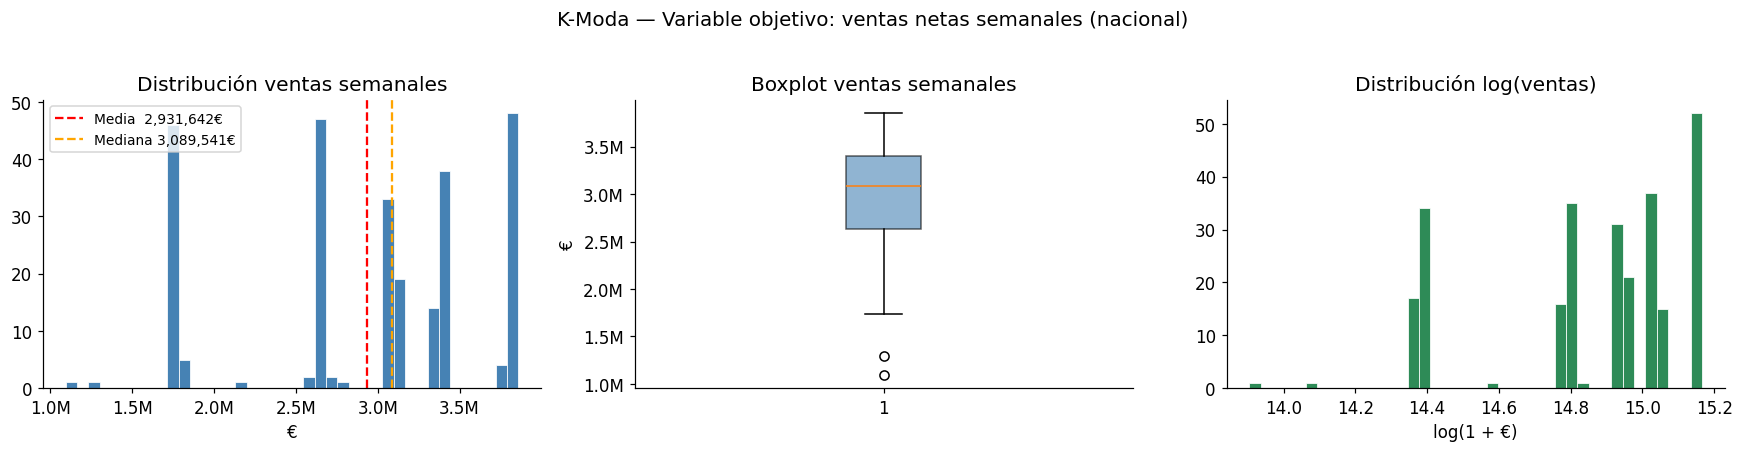

Media:            2,931,642 €
Mediana:          3,089,541 €
Std:                715,132 €
CV:                  24.4%
Asimetría:           -0.549
Curtosis:            -0.803
Shapiro p:           0.0000  → No normal


In [12]:
# ── Distribución semanal nacional ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

v = ventas_total_semanal['ventas_eur']

# Histograma
axes[0].hist(v, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(v.mean(),   color='red',    linestyle='--', label=f'Media  {v.mean():,.0f}€')
axes[0].axvline(v.median(), color='orange', linestyle='--', label=f'Mediana {v.median():,.0f}€')
axes[0].set_title('Distribución ventas semanales')
axes[0].set_xlabel('€')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Boxplot
axes[1].boxplot(v, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot ventas semanales')
axes[1].set_ylabel('€')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Log-transformación para evaluar normalidad
log_v = np.log1p(v)
axes[2].hist(log_v, bins=40, color='seagreen', edgecolor='white', linewidth=0.5)
axes[2].set_title('Distribución log(ventas)')
axes[2].set_xlabel('log(1 + €)')

plt.suptitle('K-Moda — Variable objetivo: ventas netas semanales (nacional)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Estadísticos
print(f'Media:      {v.mean():>15,.0f} €')
print(f'Mediana:    {v.median():>15,.0f} €')
print(f'Std:        {v.std():>15,.0f} €')
print(f'CV:         {v.std()/v.mean():>14.1%}')
print(f'Asimetría:  {v.skew():>15.3f}')
print(f'Curtosis:   {v.kurtosis():>15.3f}')
stat, p = stats.shapiro(v.sample(min(500, len(v)), random_state=42))
print(f'Shapiro p:  {p:>15.4f}  → {"No normal" if p < 0.05 else "Normal"}')

In [13]:
# ── Detección de outliers (IQR) ───────────────────────────────────────────────
Q1, Q3 = v.quantile(0.25), v.quantile(0.75)
IQR = Q3 - Q1
limite_sup = Q3 + 3 * IQR
limite_inf = Q1 - 3 * IQR

outliers = ventas_total_semanal[
    (ventas_total_semanal['ventas_eur'] > limite_sup) |
    (ventas_total_semanal['ventas_eur'] < limite_inf)
]
print(f'Outliers detectados (3×IQR): {len(outliers)}')
if len(outliers):
    display(outliers[['semana_inicio', 'ventas_eur']].assign(
        ventas_eur=lambda d: d['ventas_eur'].map('{:,.0f} €'.format)
    ))

Outliers detectados (3×IQR): 0


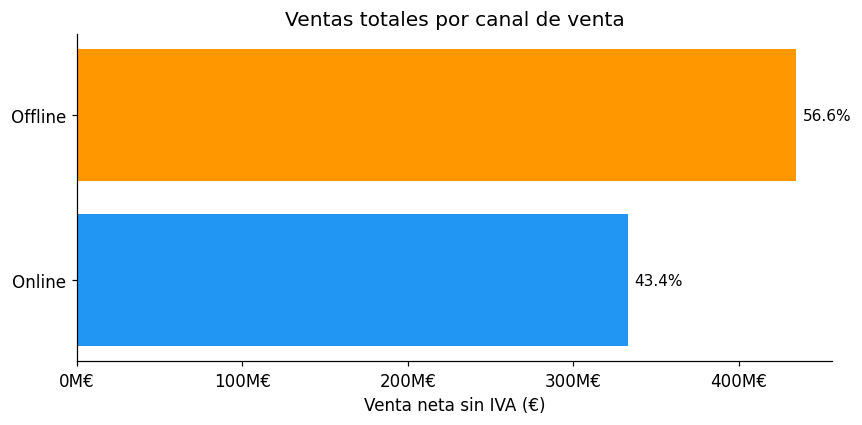

,canal_venta,ventas_eur,pct
1,Online,"333,313,183 €",43.4%
0,Offline,"434,777,072 €",56.6%


In [14]:
# ── Desglose ventas por canal (Online vs Offline) ─────────────────────────────
ventas_canal = (
    ventas_semanal
    .groupby('canal_venta', observed=True)['ventas_eur']
    .sum()
    .reset_index()
    .sort_values('ventas_eur', ascending=True)
)
ventas_canal['pct'] = ventas_canal['ventas_eur'] / ventas_canal['ventas_eur'].sum() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(ventas_canal['canal_venta'], ventas_canal['ventas_eur'],
               color=['#2196F3', '#FF9800', '#4CAF50'])
for bar, pct in zip(bars, ventas_canal['pct']):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=10)
ax.set_title('Ventas totales por canal de venta')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M€'))
ax.set_xlabel('Venta neta sin IVA (€)')
plt.tight_layout()
plt.show()
display(ventas_canal.assign(
    ventas_eur=lambda d: d['ventas_eur'].map('{:,.0f} €'.format),
    pct=lambda d: d['pct'].map('{:.1f}%'.format)
))

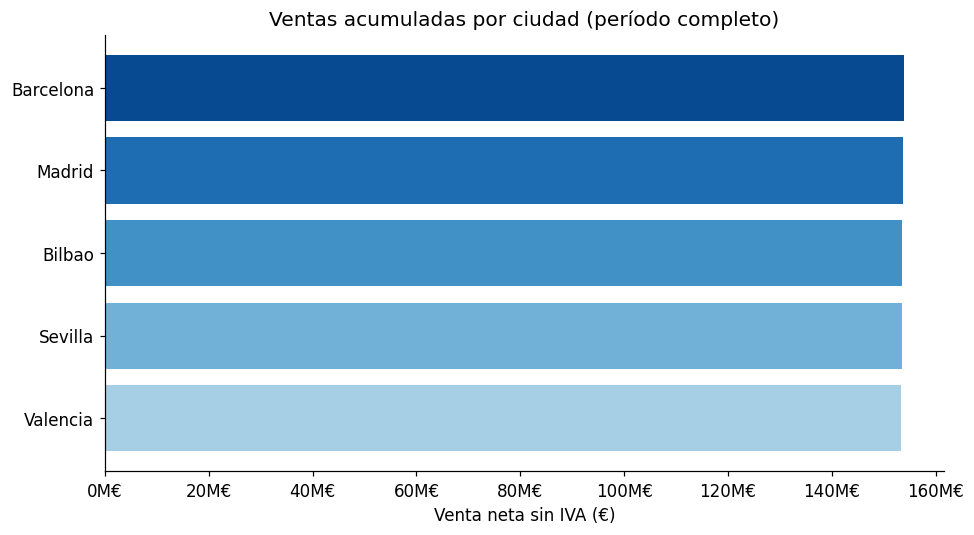

In [15]:
# ── Ventas por ciudad ─────────────────────────────────────────────────────────
ventas_ciudad = (
    ventas_semanal
    .groupby('ciudad', observed=True)['ventas_eur']
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
colores = plt.cm.Blues(np.linspace(0.35, 0.9, len(ventas_ciudad)))
ax.barh(ventas_ciudad.index, ventas_ciudad.values, color=colores)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M€'))
ax.set_title('Ventas acumuladas por ciudad (período completo)')
ax.set_xlabel('Venta neta sin IVA (€)')
plt.tight_layout()
plt.show()

---
## 6. Análisis temporal

El MMM es fundamentalmente un modelo de **serie temporal**. Necesitamos entender:
- La **tendencia** de fondo (¿crecen las ventas?)
- La **estacionalidad** (¿hay patrones anuales o semanales repetibles?)
- Los **shocks puntuales** (Black Friday, Rebajas, COVID...)

Estos componentes determinarán qué variables de control incluir en el MMM.

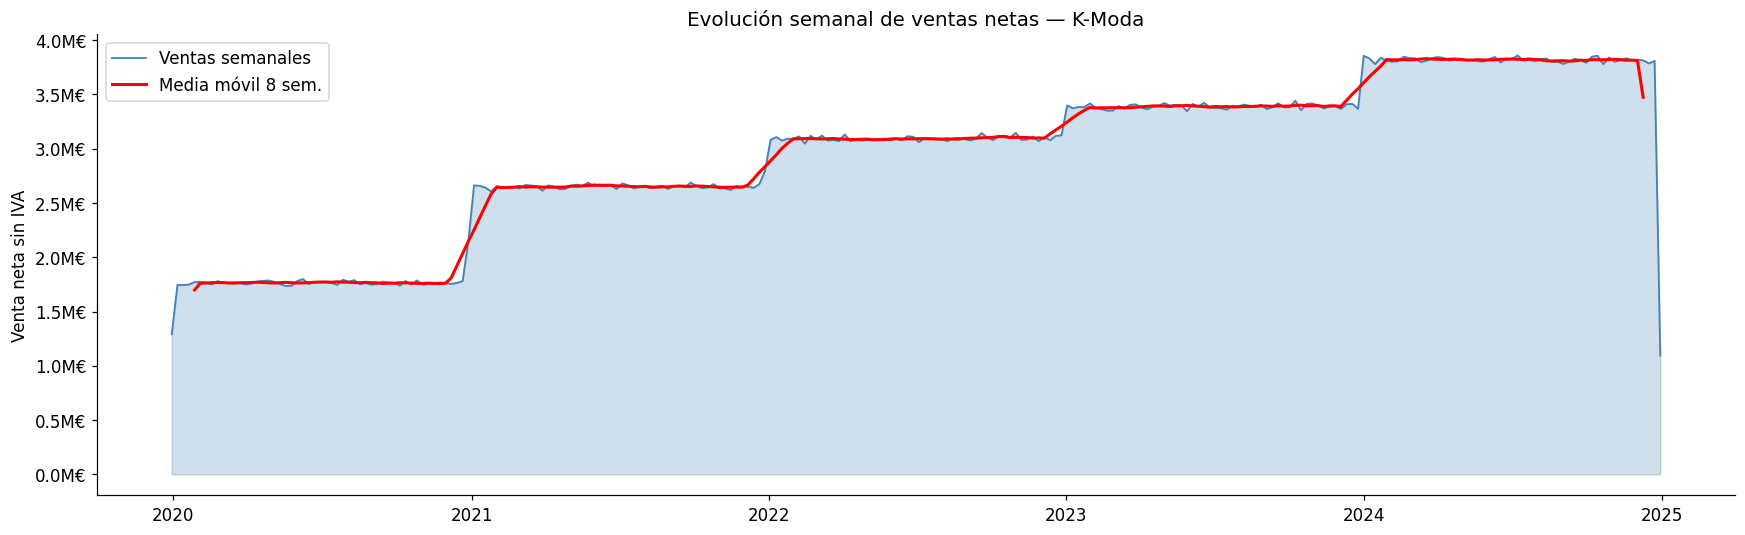

In [16]:
# ── Evolución temporal de ventas ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

ts = ventas_total_semanal.set_index('semana_inicio')['ventas_eur']
ax.fill_between(ts.index, ts.values, alpha=0.25, color='steelblue')
ax.plot(ts.index, ts.values, color='steelblue', linewidth=1.2, label='Ventas semanales')

# Media móvil 8 semanas (≈2 meses)
ma8 = ts.rolling(8, center=True).mean()
ax.plot(ma8.index, ma8.values, color='red', linewidth=2.0, label='Media móvil 8 sem.')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M€'))
ax.set_title('Evolución semanal de ventas netas — K-Moda', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Venta neta sin IVA')
ax.legend()
plt.tight_layout()
plt.show()

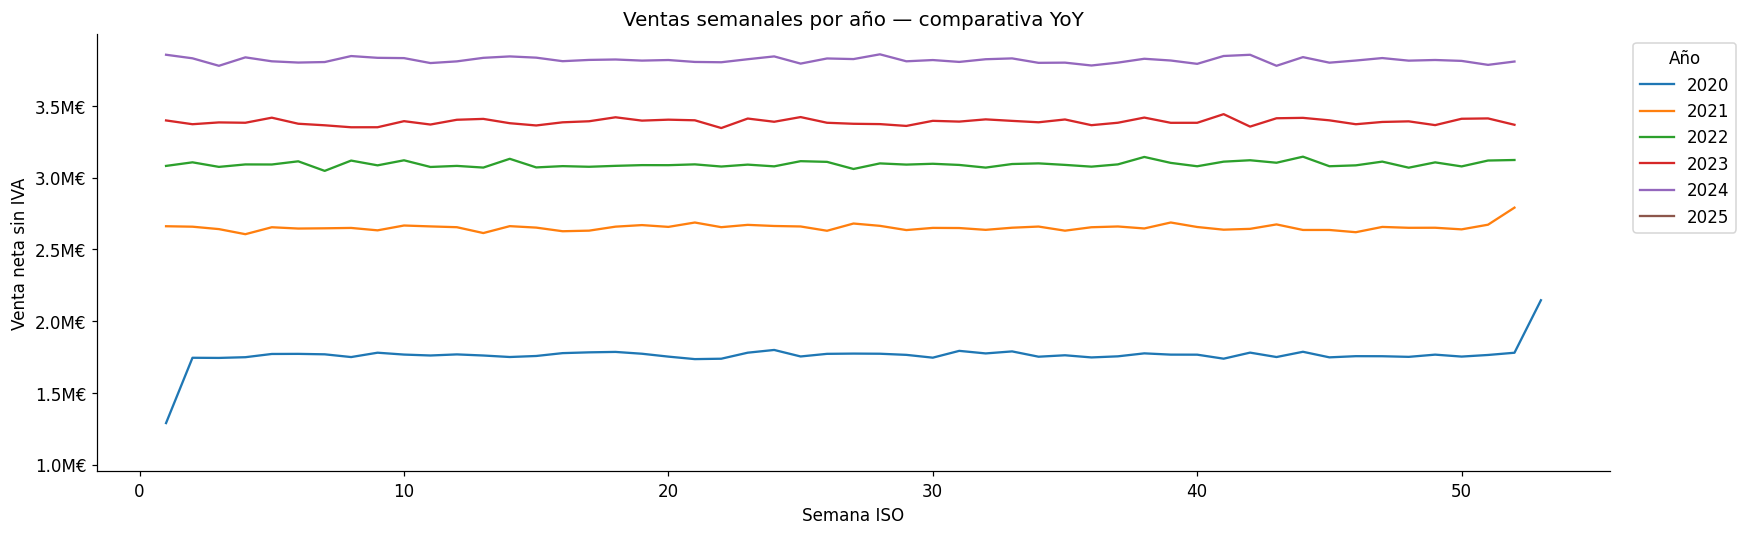

In [17]:
# ── Comparación año a año (YoY) ───────────────────────────────────────────────
ventas_total_semanal['anio']       = ventas_total_semanal['semana_inicio'].dt.isocalendar().year.astype(int)
ventas_total_semanal['semana_iso'] = ventas_total_semanal['semana_inicio'].dt.isocalendar().week.astype(int)

pivot_yoy = ventas_total_semanal.pivot_table(
    index='semana_iso', columns='anio', values='ventas_eur', aggfunc='sum'
)

fig, ax = plt.subplots(figsize=(16, 5))
for anio in pivot_yoy.columns:
    ax.plot(pivot_yoy.index, pivot_yoy[anio], label=str(anio), linewidth=1.5)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M€'))
ax.set_title('Ventas semanales por año — comparativa YoY', fontsize=13)
ax.set_xlabel('Semana ISO')
ax.set_ylabel('Venta neta sin IVA')
ax.legend(title='Año', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

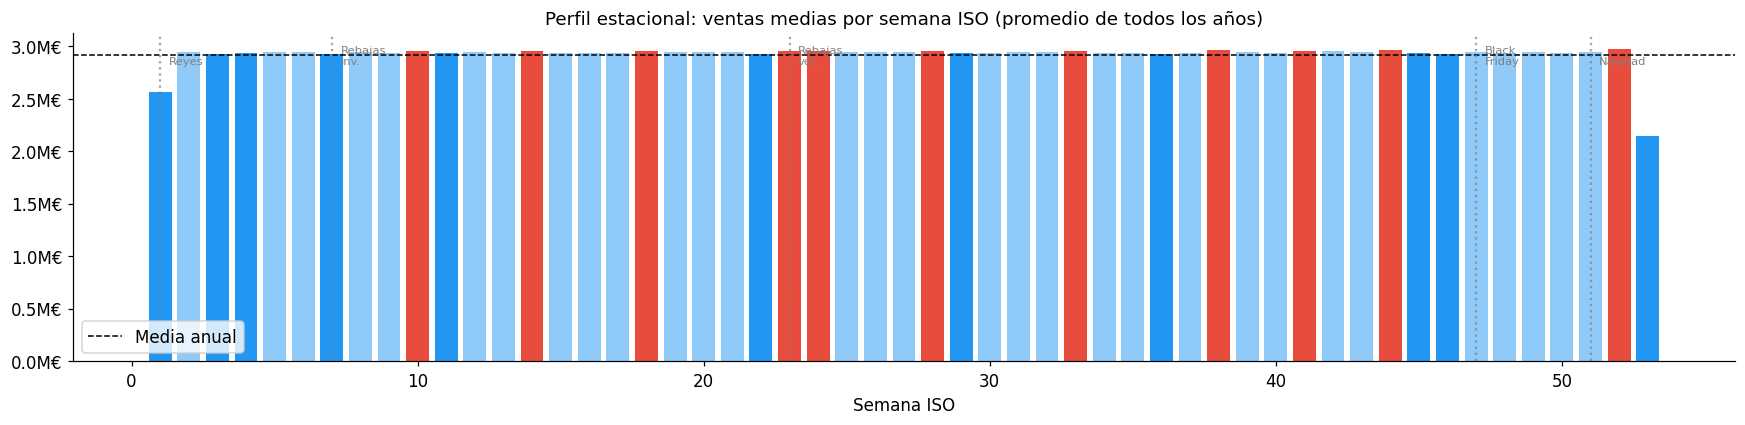

In [18]:
# ── Perfil estacional (media por semana del año) ───────────────────────────────
perfil_semanal = ventas_total_semanal.groupby('semana_iso')['ventas_eur'].mean()

fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(perfil_semanal.index, perfil_semanal.values,
       color=['#e74c3c' if (v > perfil_semanal.quantile(0.80)) else
              ('#2196F3' if v < perfil_semanal.quantile(0.20) else '#90CAF9')
              for v in perfil_semanal.values])
ax.axhline(perfil_semanal.mean(), color='black', linestyle='--', linewidth=1, label='Media anual')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M€'))
ax.set_title('Perfil estacional: ventas medias por semana ISO (promedio de todos los años)', fontsize=12)
ax.set_xlabel('Semana ISO')
ax.legend()

# Etiquetas semanas especiales
for sem, label in [(1, 'Reyes'), (7, 'Rebajas\ninv.'), (23, 'Rebajas\nver.'), (47, 'Black\nFriday'), (51, 'Navidad')]:
    ax.axvline(sem, color='gray', linestyle=':', alpha=0.7)
    ax.text(sem + 0.3, perfil_semanal.max() * 0.95, label, fontsize=7.5, color='gray')

plt.tight_layout()
plt.show()

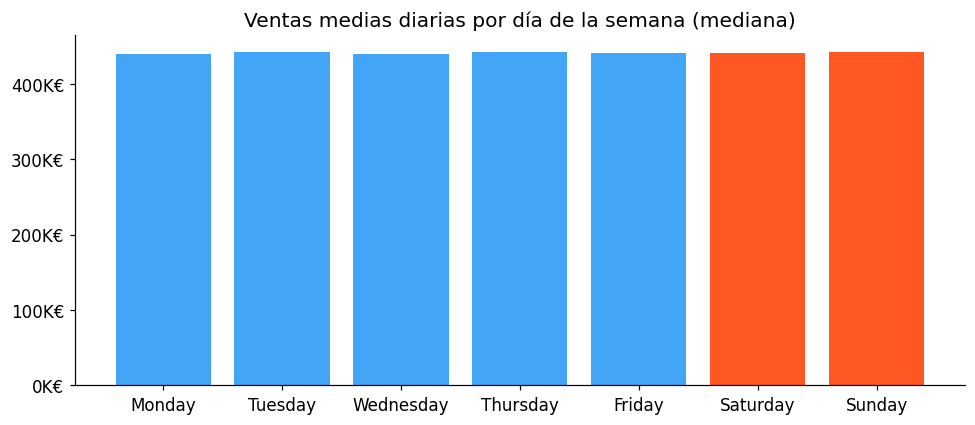

In [19]:
# ── Efecto día de la semana (desde ventas_clean o ventas_diaria) ──────────────
ventas_diaria_total = (
    ventas_diaria
    .groupby('fecha')['ventas_eur']
    .sum()
    .reset_index()
    .sort_values('fecha')
)
ventas_diaria_total['dia_semana'] = ventas_diaria_total['fecha'].dt.day_name()
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ventas_diaria_total['dia_semana'] = pd.Categorical(ventas_diaria_total['dia_semana'],
                                                    categories=orden_dias, ordered=True)

perfil_dia = ventas_diaria_total.groupby('dia_semana', observed=True)['ventas_eur'].median()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(perfil_dia.index, perfil_dia.values,
       color=['#FF5722' if d in ['Saturday', 'Sunday'] else '#42A5F5' for d in perfil_dia.index])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K€'))
ax.set_title('Ventas medias diarias por día de la semana (mediana)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

---
## 7. Análisis de variables explicativas

### 7.1 Inversión en medios

El presupuesto de medios es la principal variable **accionable** del MMM. Analizamos su distribución, evolución y estructura por canal.

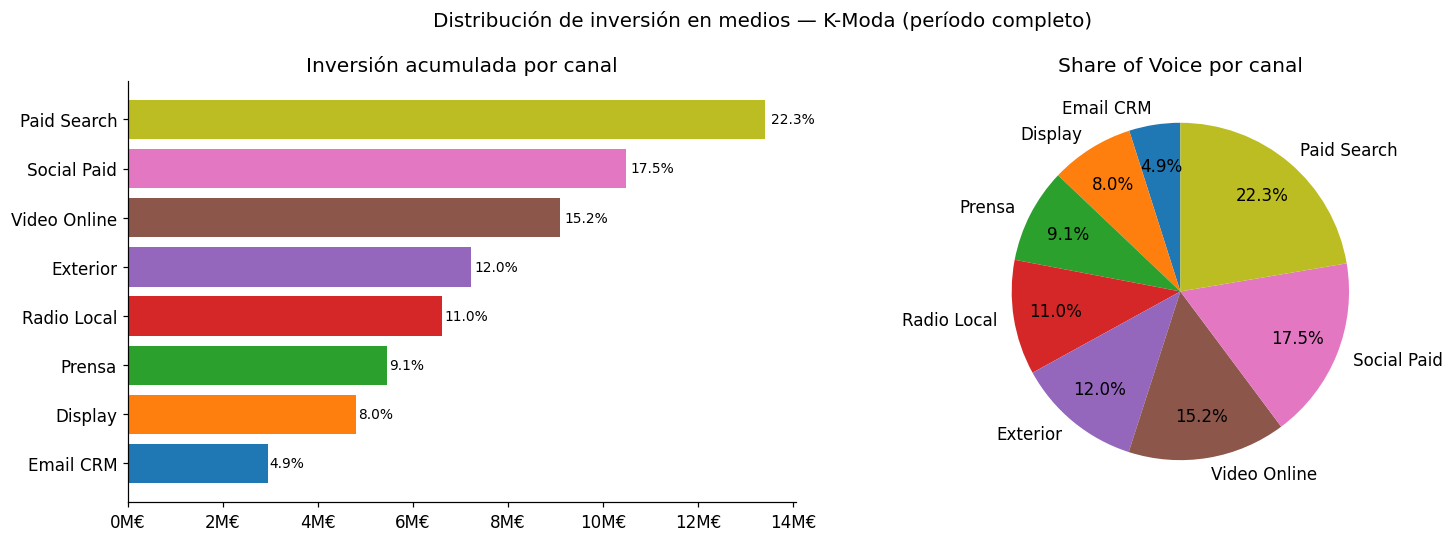

In [20]:
# ── Inversión total por canal ─────────────────────────────────────────────────
inv_canal = (
    medios.groupby('canal_medio')['inversion_eur']
    .sum()
    .sort_values(ascending=True)
)
inv_canal_pct = inv_canal / inv_canal.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras horizontales
colores_canal = plt.cm.tab10(np.linspace(0, 0.8, len(inv_canal)))
axes[0].barh(inv_canal.index, inv_canal.values, color=colores_canal)
for i, (v, pct) in enumerate(zip(inv_canal.values, inv_canal_pct.values)):
    axes[0].text(v * 1.01, i, f'{pct:.1f}%', va='center', fontsize=9)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M€'))
axes[0].set_title('Inversión acumulada por canal')

# Pie chart
axes[1].pie(inv_canal.values, labels=inv_canal.index, autopct='%1.1f%%',
            colors=colores_canal, startangle=90, pctdistance=0.75)
axes[1].set_title('Share of Voice por canal')

plt.suptitle('Distribución de inversión en medios — K-Moda (período completo)', fontsize=13)
plt.tight_layout()
plt.show()

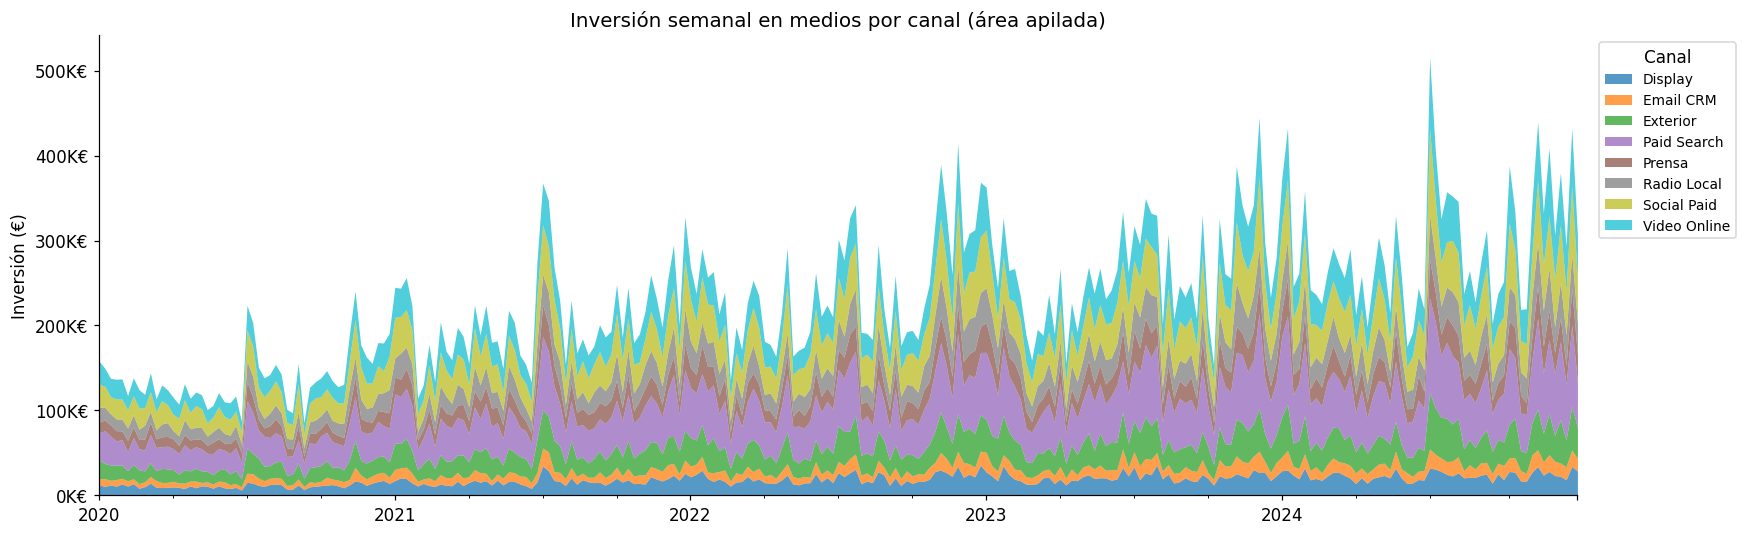

In [21]:
# ── Evolución temporal de inversión por canal ─────────────────────────────────
inv_semanal = (
    medios
    .groupby(['semana_inicio', 'canal_medio'])['inversion_eur']
    .sum()
    .reset_index()
)
pivot_inv = inv_semanal.pivot_table(index='semana_inicio', columns='canal_medio',
                                     values='inversion_eur', aggfunc='sum').fillna(0)

fig, ax = plt.subplots(figsize=(16, 5))
pivot_inv.plot.area(ax=ax, alpha=0.75, colormap='tab10', linewidth=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K€'))
ax.set_title('Inversión semanal en medios por canal (área apilada)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Inversión (€)')
ax.legend(title='Canal', bbox_to_anchor=(1.01, 1), fontsize=9)
plt.tight_layout()
plt.show()

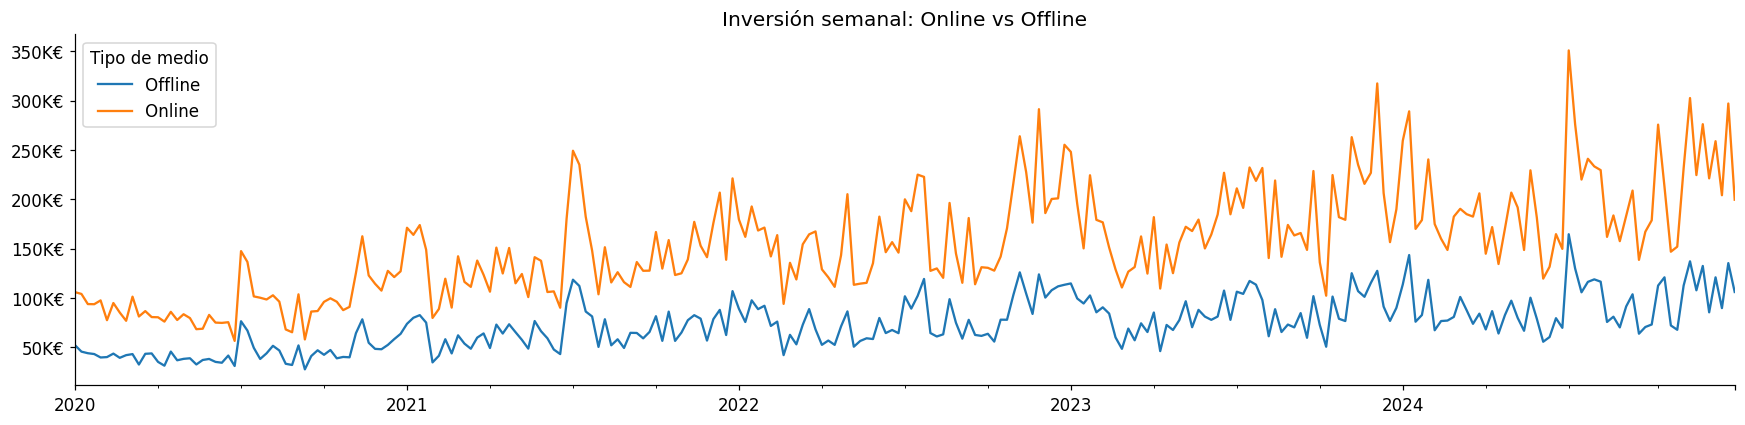

Distribución Online/Offline:
tipo_medio
Offline    19,282,580 € (32.1%)
Online     40,717,419 € (67.9%)
Name: inversion_eur, dtype: object


In [22]:
# ── Online vs Offline ─────────────────────────────────────────────────────────
inv_tipo = (
    medios.groupby(['semana_inicio', 'tipo_medio'])['inversion_eur']
    .sum()
    .reset_index()
)
pivot_tipo = inv_tipo.pivot_table(index='semana_inicio', columns='tipo_medio',
                                   values='inversion_eur', aggfunc='sum').fillna(0)

fig, ax = plt.subplots(figsize=(16, 4))
pivot_tipo.plot(ax=ax, linewidth=1.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K€'))
ax.set_title('Inversión semanal: Online vs Offline')
ax.set_xlabel('')
ax.legend(title='Tipo de medio')
plt.tight_layout()
plt.show()

print('Distribución Online/Offline:')
print(medios.groupby('tipo_medio')['inversion_eur'].sum().apply(lambda x: f'{x:,.0f} € ({x/medios["inversion_eur"].sum()*100:.1f}%)'))

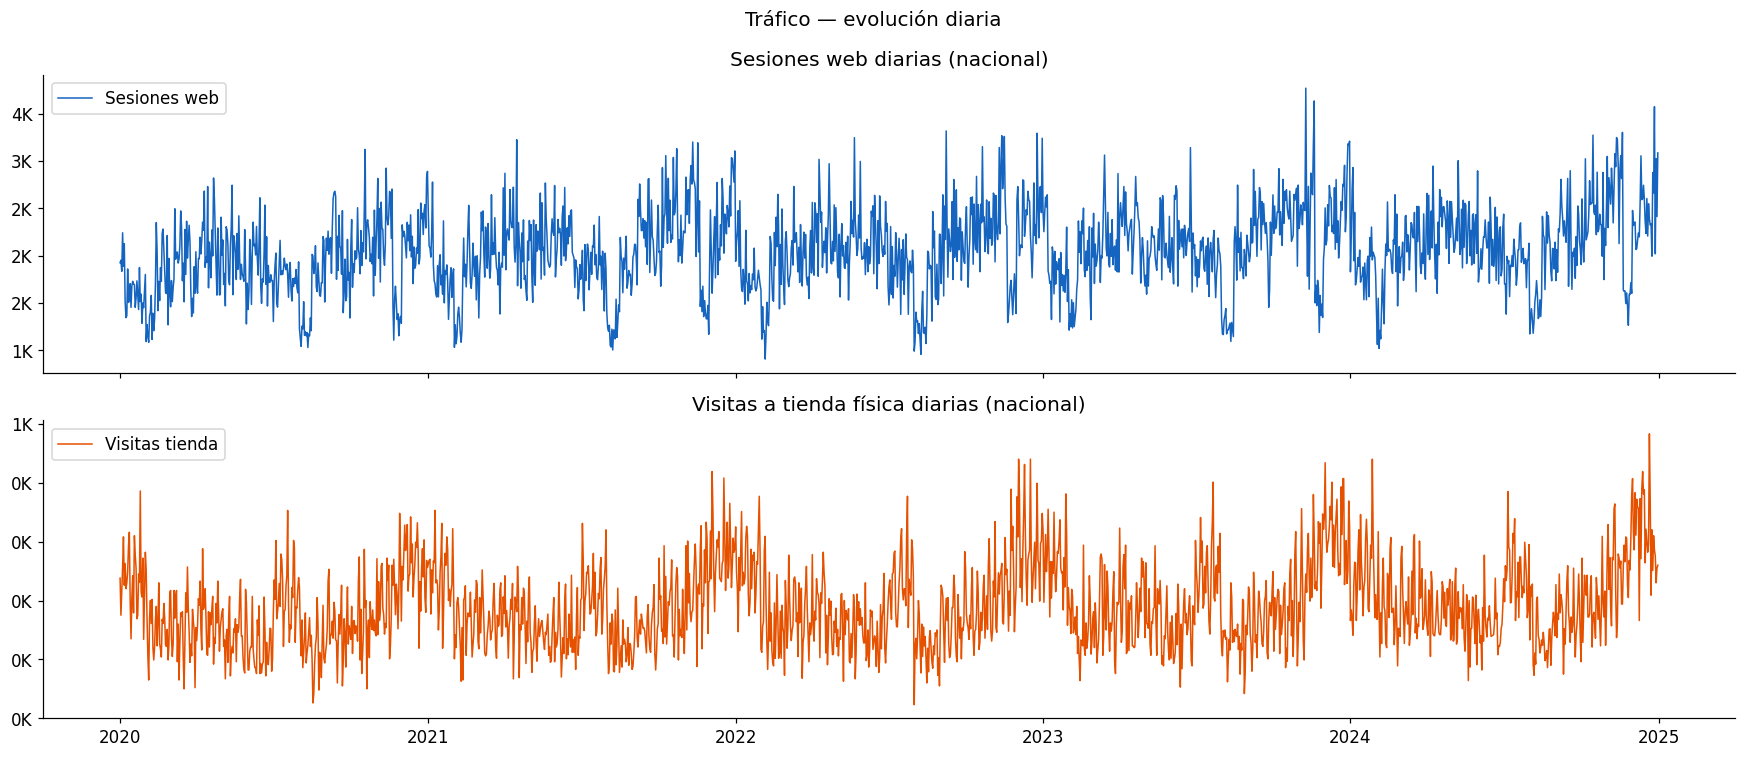

In [23]:
# ── Tráfico web y tienda ───────────────────────────────────────────────────────
trafico_nac = (
    trafico
    .groupby('fecha')
    .agg(sesiones_web=('sesiones_web','sum'), visitas_tienda=('visitas_tienda','sum'),
         pedidos_online=('pedidos_online','sum'), pedidos_tienda=('pedidos_tienda','sum'))
    .reset_index()
    .sort_values('fecha')
)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(trafico_nac['fecha'], trafico_nac['sesiones_web'],
             color='#1565C0', linewidth=1, label='Sesiones web')
axes[0].set_title('Sesiones web diarias (nacional)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[0].legend()

axes[1].plot(trafico_nac['fecha'], trafico_nac['visitas_tienda'],
             color='#E65100', linewidth=1, label='Visitas tienda')
axes[1].set_title('Visitas a tienda física diarias (nacional)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[1].legend()

plt.suptitle('Tráfico — evolución diaria', fontsize=13)
plt.tight_layout()
plt.show()

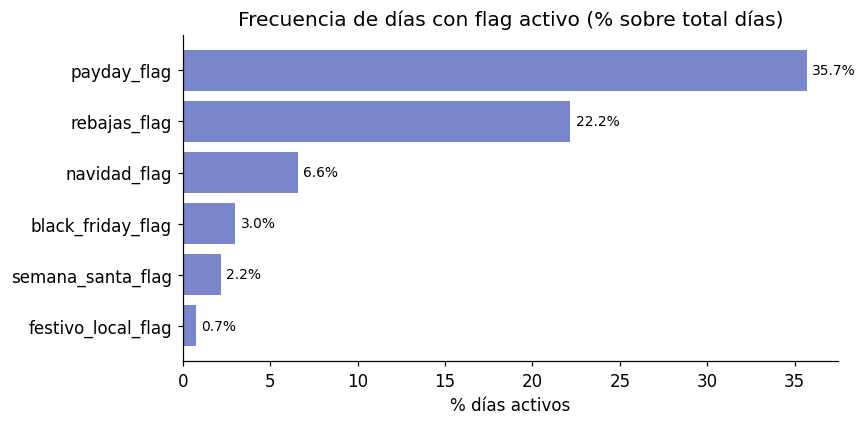

In [24]:
# ── Variables de calendario ───────────────────────────────────────────────────
FLAGS = ['rebajas_flag', 'black_friday_flag', 'navidad_flag',
         'semana_santa_flag', 'payday_flag', 'festivo_local_flag']

flag_freq = (
    calendario[FLAGS]
    .mean() * 100
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(flag_freq.index, flag_freq.values, color='#7986CB')
for i, v in enumerate(flag_freq.values):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
ax.set_title('Frecuencia de días con flag activo (% sobre total días)')
ax.set_xlabel('% días activos')
plt.tight_layout()
plt.show()

---
## 8. Construcción del dataset maestro semanal

Unificamos todas las fuentes en un único DataFrame a granularidad **semana × ciudad**, que será la unidad de análisis del MMM.  

**Decisión de granularidad:** La inversión en medios solo está disponible a nivel semanal, lo que fija el nivel mínimo. Trabajar a nivel ciudad añade dimensión geográfica útil para capturar efectos de mercado local.

In [25]:
# ── Inversión semanal por ciudad × canal (pivot) ──────────────────────────────
inv_pivot = (
    medios
    .groupby(['semana_inicio', 'ciudad', 'canal_medio'])['inversion_eur']
    .sum()
    .reset_index()
    .pivot_table(index=['semana_inicio', 'ciudad'], columns='canal_medio',
                 values='inversion_eur', aggfunc='sum')
    .fillna(0)
    .reset_index()
)
# Renombramos columnas
inv_pivot.columns = [
    c if c in ['semana_inicio', 'ciudad'] else f'inv_{c.lower().replace(" ", "_")}'
    for c in inv_pivot.columns
]
inv_pivot['inv_total'] = inv_pivot[[c for c in inv_pivot.columns if c.startswith('inv_') and c != 'inv_total']].sum(axis=1)
print('Inversión pivotada:', inv_pivot.shape)

# ── Tráfico semanal × ciudad ──────────────────────────────────────────────────
trafico['semana_inicio'] = trafico['fecha'].dt.to_period('W').apply(lambda p: p.start_time)
trafico_semanal = (
    trafico
    .groupby(['semana_inicio', 'ciudad'])
    .agg(sesiones_web=('sesiones_web','sum'), visitas_tienda=('visitas_tienda','sum'),
         pedidos_online=('pedidos_online','sum'), pedidos_tienda=('pedidos_tienda','sum'))
    .reset_index()
)

# ── Calendario semanal × ciudad ───────────────────────────────────────────────
calendario['semana_inicio'] = calendario['fecha'].dt.to_period('W').apply(lambda p: p.start_time)
cal_semanal = (
    calendario
    .groupby(['semana_inicio', 'ciudad'])
    .agg(
        dias_rebajas          = ('rebajas_flag','sum'),
        dias_black_friday     = ('black_friday_flag','sum'),
        dias_navidad          = ('navidad_flag','sum'),
        dias_semana_santa     = ('semana_santa_flag','sum'),
        dias_payday           = ('payday_flag','sum'),
        dias_festivo          = ('festivo_local_flag','sum'),
        temperatura_media     = ('temperatura_media_c','mean'),
        lluvia_media          = ('lluvia_indice','mean'),
    )
    .reset_index()
)

# ── Ventas semanales × ciudad ─────────────────────────────────────────────────
ventas_ciudad_sem = (
    ventas_semanal
    .groupby(['semana_inicio', 'ciudad'], observed=True)
    .agg(ventas_eur=('ventas_eur','sum'), unidades=('unidades','sum'),
         margen_eur=('margen_eur','sum'))
    .reset_index()
)

# ── Join maestro ──────────────────────────────────────────────────────────────
master = (
    ventas_ciudad_sem
    .merge(inv_pivot,       on=['semana_inicio', 'ciudad'], how='left')
    .merge(trafico_semanal, on=['semana_inicio', 'ciudad'], how='left')
    .merge(cal_semanal,     on=['semana_inicio', 'ciudad'], how='left')
    .sort_values(['ciudad', 'semana_inicio'])
    .reset_index(drop=True)
)

# Año y semana
master['anio']       = master['semana_inicio'].dt.isocalendar().year.astype(int)
master['semana_iso'] = master['semana_inicio'].dt.isocalendar().week.astype(int)

print(f'Dataset maestro: {master.shape}')
print(f'Periodo: {master["semana_inicio"].min().date()} → {master["semana_inicio"].max().date()}')
print(f'Ciudades: {master["ciudad"].nunique()}')
print(f'Nulos en inv_total: {master["inv_total"].isna().sum()} '
      f'({master["inv_total"].isna().mean():.1%})')
master.head(3)

Inversión pivotada: (2610, 11)
Dataset maestro: (1310, 28)
Periodo: 2019-12-30 → 2024-12-30
Ciudades: 5
Nulos en inv_total: 5 (0.4%)


,semana_inicio,ciudad,ventas_eur,unidades,margen_eur,inv_display,inv_email_crm,inv_exterior,inv_paid_search,inv_prensa,...,dias_rebajas,dias_black_friday,dias_navidad,dias_semana_santa,dias_payday,dias_festivo,temperatura_media,lluvia_media,anio,semana_iso
0,2019-12-30,Barcelona,254999.88,6714,155531.15,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,5,0,10.920000,48.640000,2020,1
1,2020-01-06,Barcelona,349868.95,9143,213578.48,1748.40,267.81,2797.06,3894.21,2216.74,...,6,0,0,0,0,0,11.142857,57.071429,2020,2
2,2020-01-13,Barcelona,358427.61,9304,218085.71,1274.28,1349.57,1943.18,5033.46,2162.01,...,7,0,0,0,0,0,9.900000,58.471429,2020,3


In [26]:
# ── Cobertura del join: ¿hay semanas sin inversión o sin ventas? ───────────────
master_nulos = master[master['inv_total'].isna()][['semana_inicio', 'ciudad', 'ventas_eur', 'inv_total']]
print(f'Semanas sin datos de inversión: {len(master_nulos)}')

# Rellenamos NaN de inversión con 0 (no hubo inversión ese período)
inv_cols = [c for c in master.columns if c.startswith('inv_')]
master[inv_cols] = master[inv_cols].fillna(0)

# Guardar dataset maestro
master.to_csv(PROC / '01_master_semanal.csv', index=False)
print(f'Dataset maestro guardado en: {PROC / "01_master_semanal.csv"}')

Semanas sin datos de inversión: 5
Dataset maestro guardado en: ..\data\processed\01_master_semanal.csv


---
## 9. Correlaciones iniciales

Calculamos correlaciones lineales (Pearson) entre ventas y variables explicativas **sin ajustar por lag** aún. Es un primer filtro para identificar relaciones directas.  

> ⚠️ **Advertencia de interpretación:** La correlación contemporánea puede subestimar el impacto real de medios que tienen efecto retardado (paid search puede tener efecto inmediato; TV o branding pueden tardar semanas).

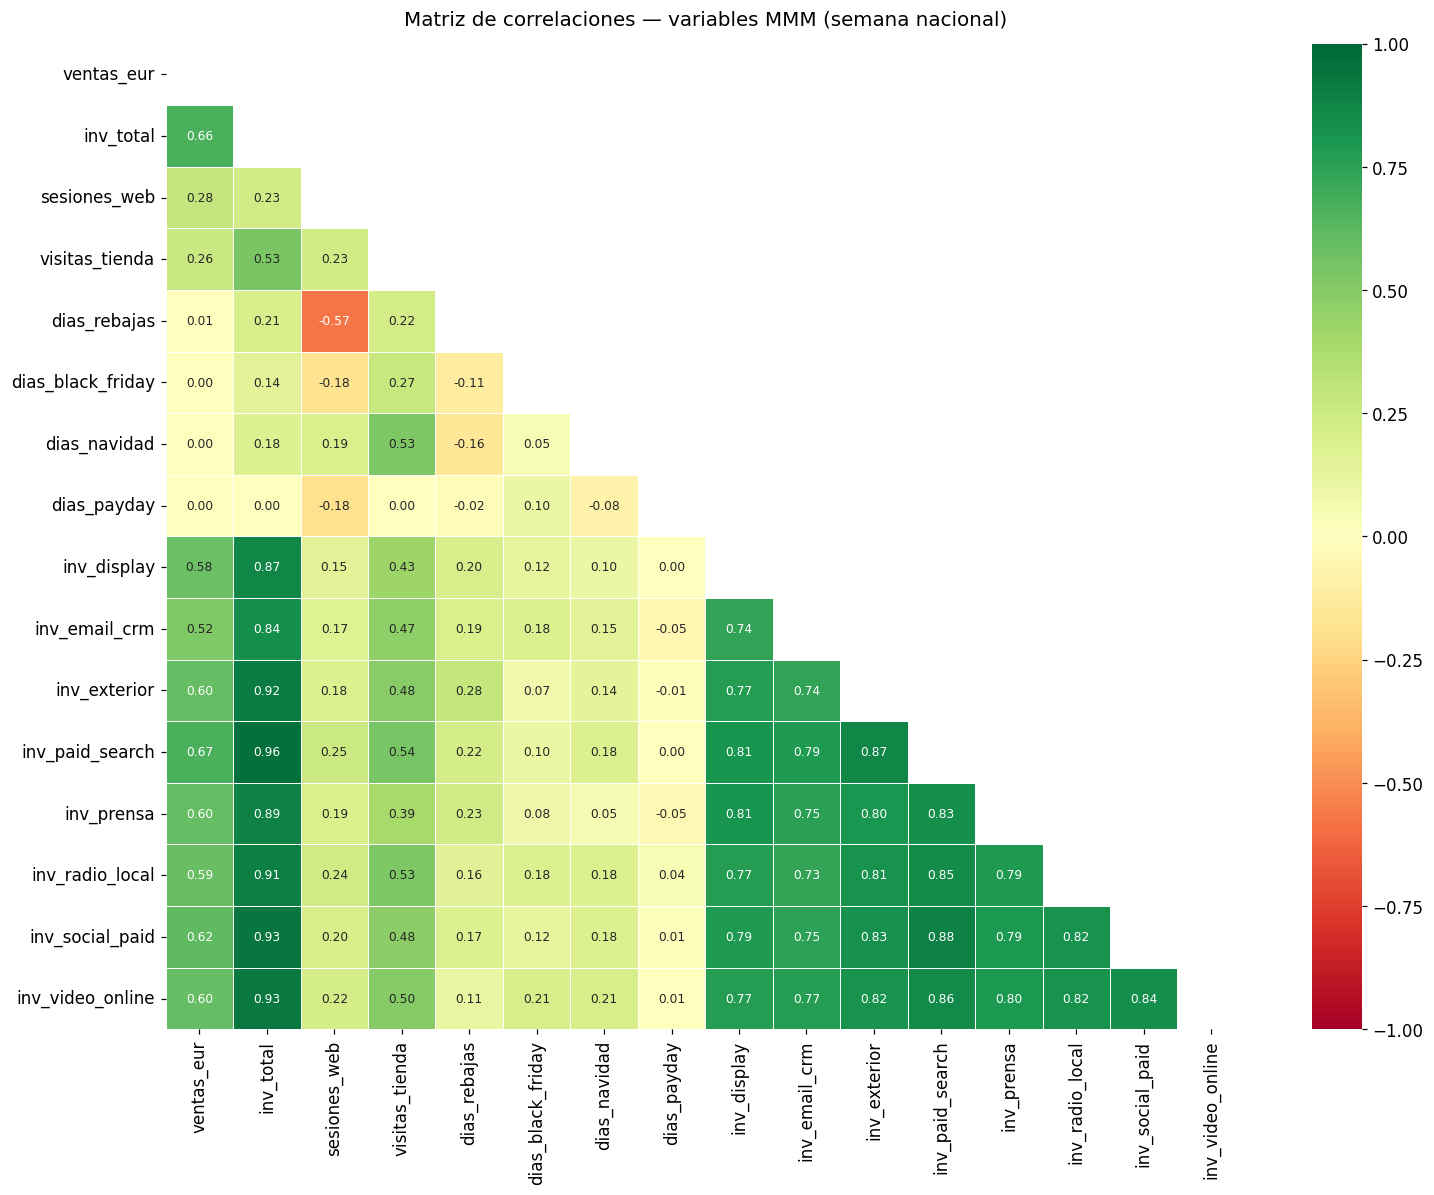

In [27]:
# ── Heatmap de correlaciones (nivel nacional) ─────────────────────────────────
master_nac = (
    master
    .groupby('semana_inicio')
    .agg({c: 'sum' for c in master.select_dtypes('number').columns
          if c not in ['anio', 'semana_iso']})
    .reset_index()
    .sort_values('semana_inicio')
)

cols_corr = ['ventas_eur', 'inv_total', 'sesiones_web', 'visitas_tienda',
             'dias_rebajas', 'dias_black_friday', 'dias_navidad', 'dias_payday'] + \
            [c for c in master_nac.columns if c.startswith('inv_') and c != 'inv_total']
cols_corr = [c for c in cols_corr if c in master_nac.columns]

corr_matrix = master_nac[cols_corr].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Matriz de correlaciones — variables MMM (semana nacional)', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

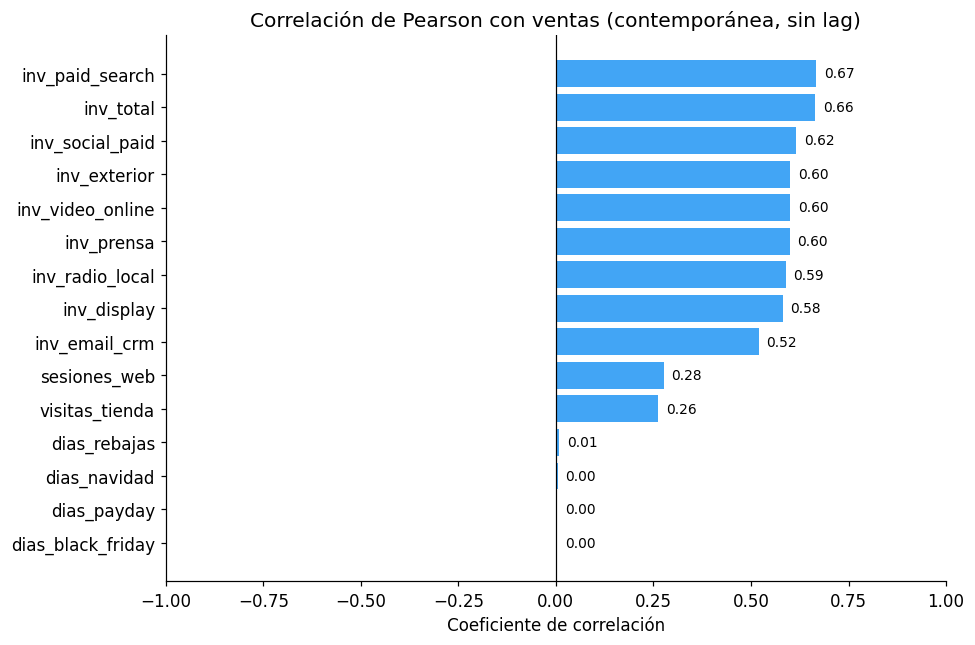

In [28]:
# ── Correlación de cada variable con ventas ───────────────────────────────────
corr_ventas = (
    corr_matrix['ventas_eur']
    .drop('ventas_eur')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 6))
colores = ['#EF5350' if v < 0 else '#42A5F5' for v in corr_ventas.values]
ax.barh(corr_ventas.index, corr_ventas.values, color=colores)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-1, 1)
ax.set_title('Correlación de Pearson con ventas (contemporánea, sin lag)')
ax.set_xlabel('Coeficiente de correlación')
for i, v in enumerate(corr_ventas.values):
    ax.text(v + (0.02 if v >= 0 else -0.02), i, f'{v:.2f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

---
## 10. Análisis avanzado orientado al MMM

Esta sección va más allá del EDA estándar. Exploramos tres conceptos fundamentales del MMM:

1. **Lag (retardo):** La inversión en medios no genera ventas al instante; el efecto puede tardar días o semanas.
2. **Adstock:** Los efectos de la publicidad se acumulan y decaen exponencialmente (memoria del consumidor).
3. **Saturación:** A partir de cierta inversión, el retorno marginal decrece (ley de los rendimientos decrecientes).

> Estos análisis son **exploratorios**: sirven para informar los hiperparámetros del modelo, no para concluir causalidad.

### 10.1 Análisis de lag (retardo entre inversión y ventas)

Calculamos la correlación entre ventas de la semana `t` e inversión en la semana `t-k` para k=0,1,...,8.  
El lag con mayor correlación sugiere la **ventana de efecto** de ese canal.

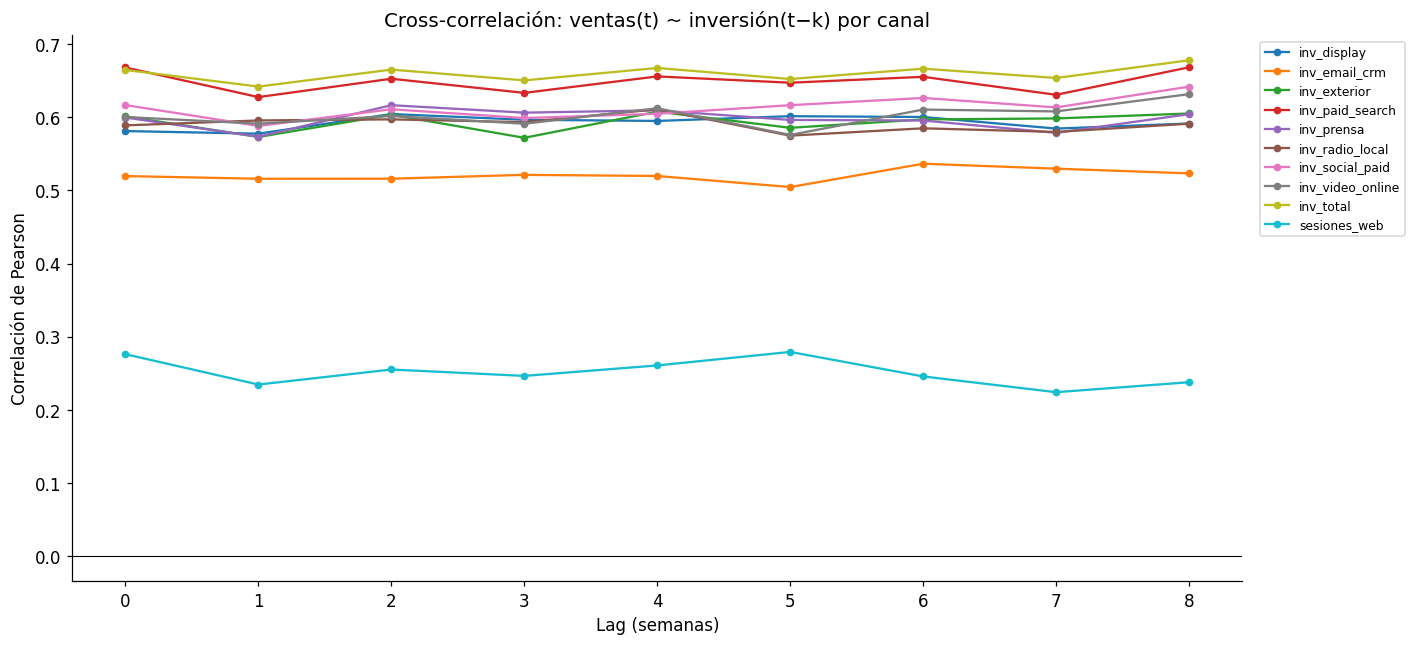


Lag óptimo por canal (máxima correlación positiva):
  inv_display                         lag=2 sem  |  corr=0.604
  inv_email_crm                       lag=6 sem  |  corr=0.536
  inv_exterior                        lag=4 sem  |  corr=0.607
  inv_paid_search                     lag=8 sem  |  corr=0.668
  inv_prensa                          lag=2 sem  |  corr=0.616
  inv_radio_local                     lag=4 sem  |  corr=0.611
  inv_social_paid                     lag=8 sem  |  corr=0.642
  inv_video_online                    lag=8 sem  |  corr=0.631
  inv_total                           lag=8 sem  |  corr=0.678
  sesiones_web                        lag=5 sem  |  corr=0.279


In [29]:
# ── Cross-correlación ventas ~ inversión por canal ────────────────────────────
MAX_LAG = 8  # semanas

canales_inv = [c for c in master_nac.columns if c.startswith('inv_') and c != 'inv_total']
lag_results = {}

for canal in canales_inv + ['inv_total', 'sesiones_web']:
    if canal not in master_nac.columns:
        continue
    corrs = []
    for lag in range(0, MAX_LAG + 1):
        c = master_nac['ventas_eur'].corr(master_nac[canal].shift(lag))
        corrs.append(c)
    lag_results[canal] = corrs

df_lag = pd.DataFrame(lag_results, index=range(MAX_LAG + 1))
df_lag.index.name = 'lag_semanas'

# Visualización
fig, ax = plt.subplots(figsize=(13, 6))
for canal in df_lag.columns:
    ax.plot(df_lag.index, df_lag[canal], marker='o', markersize=4, label=canal, linewidth=1.5)

ax.axhline(0, color='black', linewidth=0.7)
ax.set_title('Cross-correlación: ventas(t) ~ inversión(t−k) por canal', fontsize=13)
ax.set_xlabel('Lag (semanas)')
ax.set_ylabel('Correlación de Pearson')
ax.legend(bbox_to_anchor=(1.01, 1), fontsize=8)
ax.set_xticks(range(MAX_LAG + 1))
plt.tight_layout()
plt.show()

# Lag óptimo por canal
print('\nLag óptimo por canal (máxima correlación positiva):')
for canal in df_lag.columns:
    optimal_lag = df_lag[canal].idxmax()
    max_corr    = df_lag[canal].max()
    print(f'  {canal:<35} lag={optimal_lag} sem  |  corr={max_corr:.3f}')

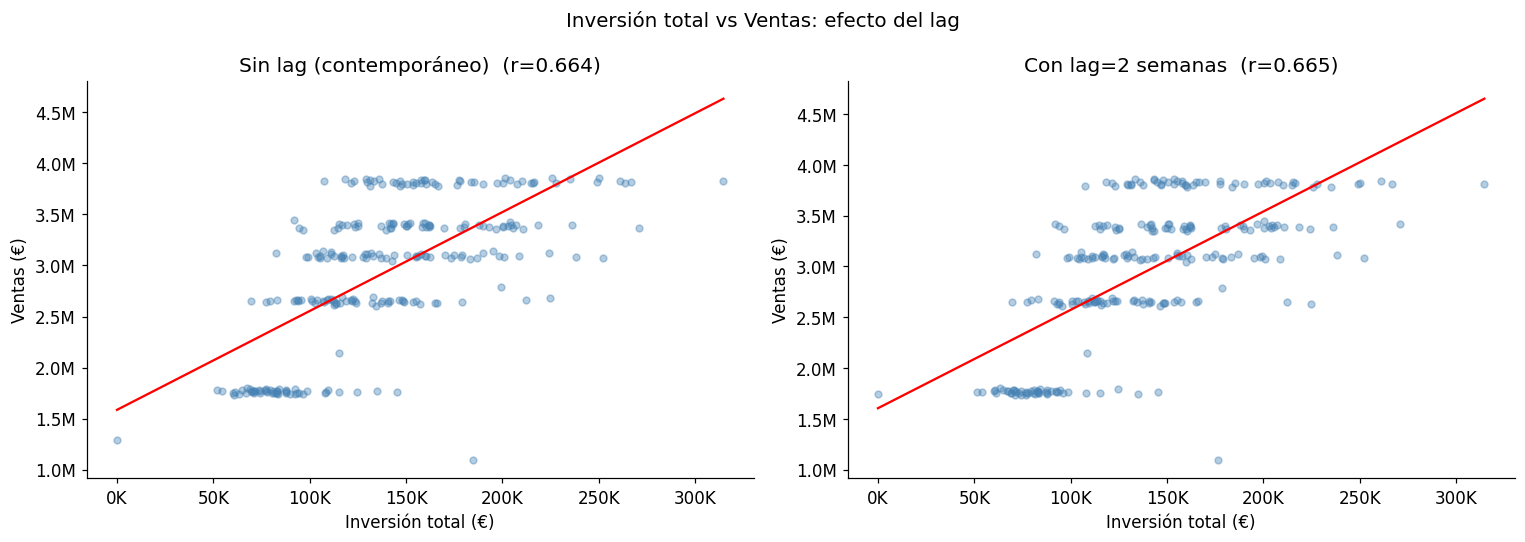

In [30]:
# ── Scatter: inversión total vs ventas con y sin lag ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, lag, titulo in zip(axes, [0, 2], ['Sin lag (contemporáneo)', 'Con lag=2 semanas']):
    x = master_nac['inv_total'].shift(lag)
    y = master_nac['ventas_eur']
    mask = x.notna() & y.notna()
    r = np.corrcoef(x[mask], y[mask])[0, 1]

    ax.scatter(x[mask], y[mask], alpha=0.4, s=20, color='steelblue')
    # Línea de tendencia
    z = np.polyfit(x[mask], y[mask], 1)
    p = np.poly1d(z)
    xr = np.linspace(x[mask].min(), x[mask].max(), 100)
    ax.plot(xr, p(xr), color='red', linewidth=1.5)
    ax.set_title(f'{titulo}  (r={r:.3f})')
    ax.set_xlabel('Inversión total (€)')
    ax.set_ylabel('Ventas (€)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle('Inversión total vs Ventas: efecto del lag', fontsize=13)
plt.tight_layout()
plt.show()

### 10.2 Adstock — memoria acumulada de la publicidad

El **adstock geométrico** modela que el efecto de un euro invertido en la semana `t` no desaparece del todo en `t+1`:  

$$A_t = x_t + \lambda \cdot A_{t-1}$$

donde $\lambda \in [0,1)$ es la **tasa de retención** (decay). Un $\lambda$ alto implica que la memoria publicitaria dura muchas semanas.

Exploramos distintos valores de $\lambda$ y medimos su correlación con ventas para estimar el decay óptimo por canal.

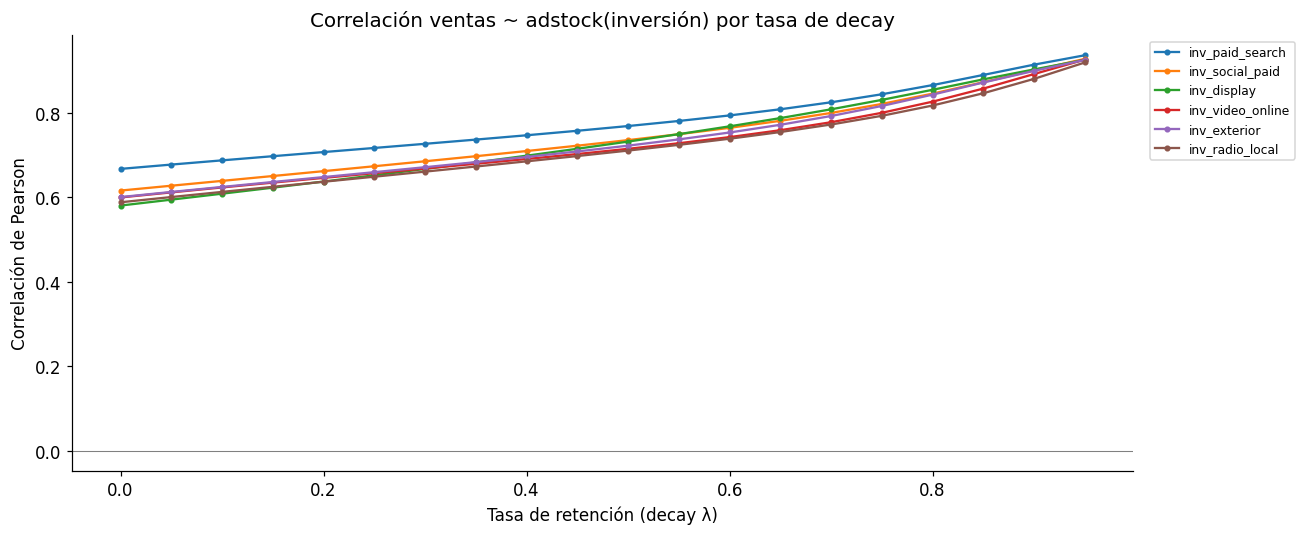


Decay óptimo por canal (máxima correlación):
  inv_paid_search                λ_opt=0.95  |  corr=0.937
  inv_social_paid                λ_opt=0.95  |  corr=0.928
  inv_display                    λ_opt=0.95  |  corr=0.926
  inv_video_online               λ_opt=0.95  |  corr=0.926
  inv_exterior                   λ_opt=0.95  |  corr=0.926
  inv_radio_local                λ_opt=0.95  |  corr=0.920


In [31]:
def adstock_geometrico(serie: pd.Series, decay: float) -> pd.Series:
    """Transforma una serie de inversión con adstock geométrico."""
    resultado = np.zeros(len(serie))
    resultado[0] = serie.iloc[0]
    for i in range(1, len(serie)):
        resultado[i] = serie.iloc[i] + decay * resultado[i - 1]
    return pd.Series(resultado, index=serie.index)

# ── Búsqueda de decay óptimo para cada canal ──────────────────────────────────
DECAYS = np.arange(0.0, 1.0, 0.05)
canales_eval = ['inv_paid_search', 'inv_social_paid', 'inv_display',
                'inv_video_online', 'inv_exterior', 'inv_radio_local']
canales_eval = [c for c in canales_eval if c in master_nac.columns]

decay_results = {}
for canal in canales_eval:
    corrs = []
    for d in DECAYS:
        ads = adstock_geometrico(master_nac[canal].fillna(0), d)
        c   = master_nac['ventas_eur'].corr(ads)
        corrs.append(c)
    decay_results[canal] = corrs

df_decay = pd.DataFrame(decay_results, index=DECAYS.round(2))
df_decay.index.name = 'decay_rate'

fig, ax = plt.subplots(figsize=(12, 5))
for canal in df_decay.columns:
    ax.plot(df_decay.index, df_decay[canal], marker='o', markersize=3, label=canal, linewidth=1.5)

ax.set_title('Correlación ventas ~ adstock(inversión) por tasa de decay', fontsize=13)
ax.set_xlabel('Tasa de retención (decay λ)')
ax.set_ylabel('Correlación de Pearson')
ax.legend(bbox_to_anchor=(1.01, 1), fontsize=8)
ax.axhline(0, color='gray', linewidth=0.7)
plt.tight_layout()
plt.show()

print('\nDecay óptimo por canal (máxima correlación):')
for canal in df_decay.columns:
    opt = df_decay[canal].idxmax()
    max_c = df_decay[canal].max()
    print(f'  {canal:<30} λ_opt={opt:.2f}  |  corr={max_c:.3f}')

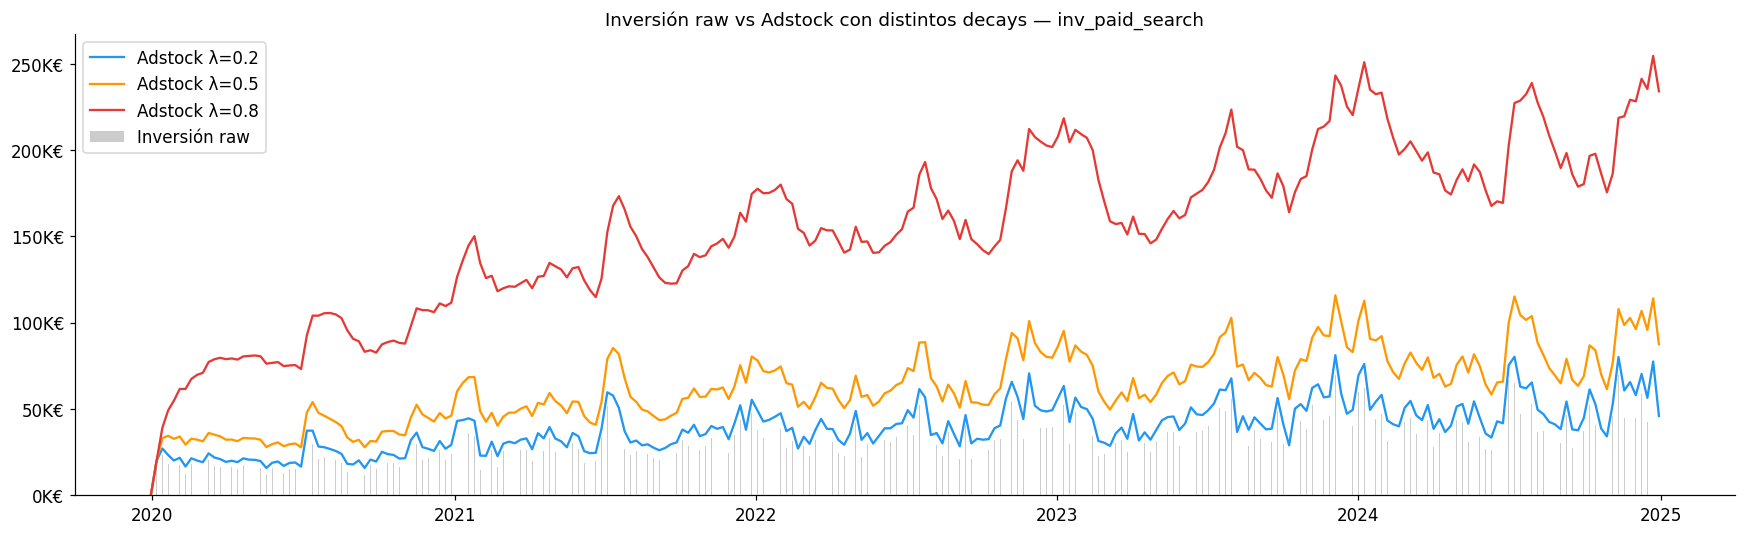

In [32]:
# ── Visualización del efecto adstock sobre Paid Search ────────────────────────
canal_demo = 'inv_paid_search' if 'inv_paid_search' in master_nac.columns else canales_eval[0]
serie_raw  = master_nac[canal_demo].fillna(0)

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(master_nac['semana_inicio'], serie_raw, alpha=0.4, color='gray', label='Inversión raw')

for decay, color in [(0.2, '#2196F3'), (0.5, '#FF9800'), (0.8, '#E53935')]:
    ads = adstock_geometrico(serie_raw, decay)
    ax.plot(master_nac['semana_inicio'], ads, linewidth=1.5,
            label=f'Adstock λ={decay}', color=color)

ax.set_title(f'Inversión raw vs Adstock con distintos decays — {canal_demo}', fontsize=12)
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K€'))
ax.legend()
plt.tight_layout()
plt.show()

### 10.3 Saturación — rendimientos decrecientes de la inversión

A partir de cierto nivel de inversión, cada euro adicional genera **menos retorno** (saturación).  
Modelamos esto con la **función Hill**, común en MMM bayesianos:

$$f(x) = \frac{x^S}{K^S + x^S}$$

donde $K$ es el punto de media saturación y $S$ controla la curvatura.

El análisis exploratorio de saturación ayuda a identificar si el presupuesto actual está en zona de **infrainversión** (alta rentabilidad marginal) o **sobreinversión** (rendimientos muy bajos).

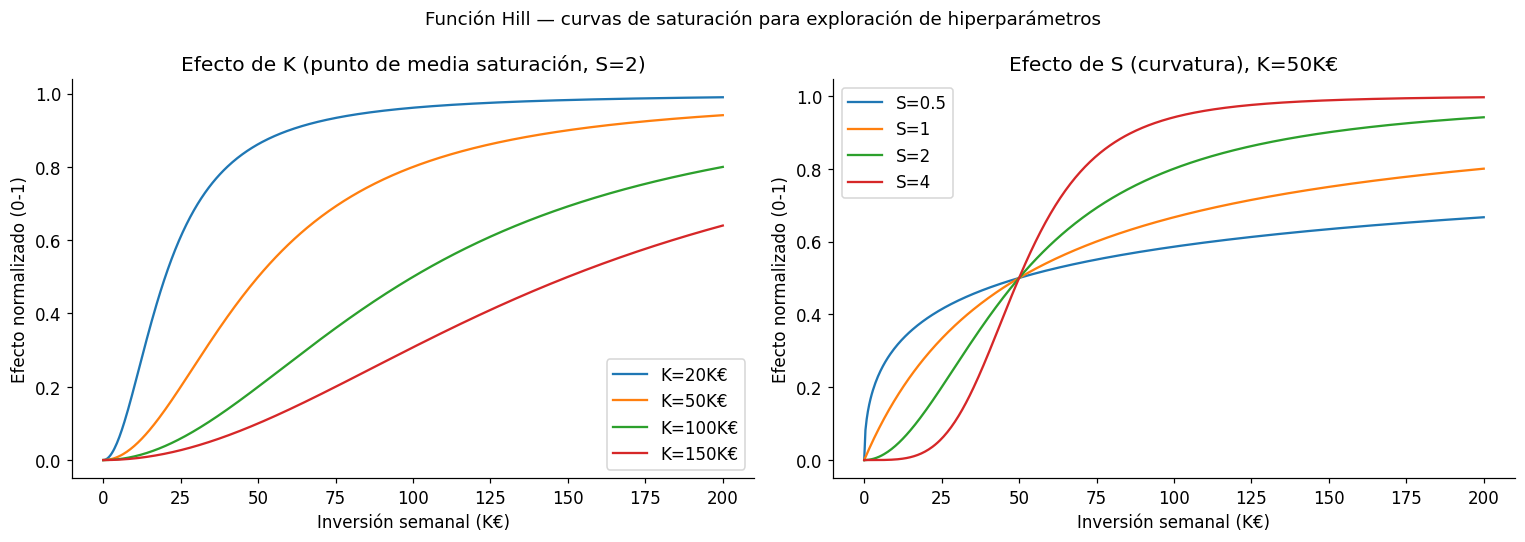

In [33]:
def hill_saturation(x, K, S):
    """Función Hill para modelar saturación (rendimientos decrecientes)."""
    return x**S / (K**S + x**S)

# ── Curvas de saturación teóricas (diferentes K y S) ─────────────────────────
x_range = np.linspace(0, 200_000, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Efecto del K (punto de saturación)
for K in [20_000, 50_000, 100_000, 150_000]:
    axes[0].plot(x_range / 1e3, hill_saturation(x_range, K=K, S=2),
                 label=f'K={K/1e3:.0f}K€')
axes[0].set_title('Efecto de K (punto de media saturación, S=2)')
axes[0].set_xlabel('Inversión semanal (K€)')
axes[0].set_ylabel('Efecto normalizado (0-1)')
axes[0].legend()

# Efecto del S (curvatura)
for S in [0.5, 1, 2, 4]:
    axes[1].plot(x_range / 1e3, hill_saturation(x_range, K=50_000, S=S),
                 label=f'S={S}')
axes[1].set_title('Efecto de S (curvatura), K=50K€')
axes[1].set_xlabel('Inversión semanal (K€)')
axes[1].set_ylabel('Efecto normalizado (0-1)')
axes[1].legend()

plt.suptitle('Función Hill — curvas de saturación para exploración de hiperparámetros', fontsize=12)
plt.tight_layout()
plt.show()

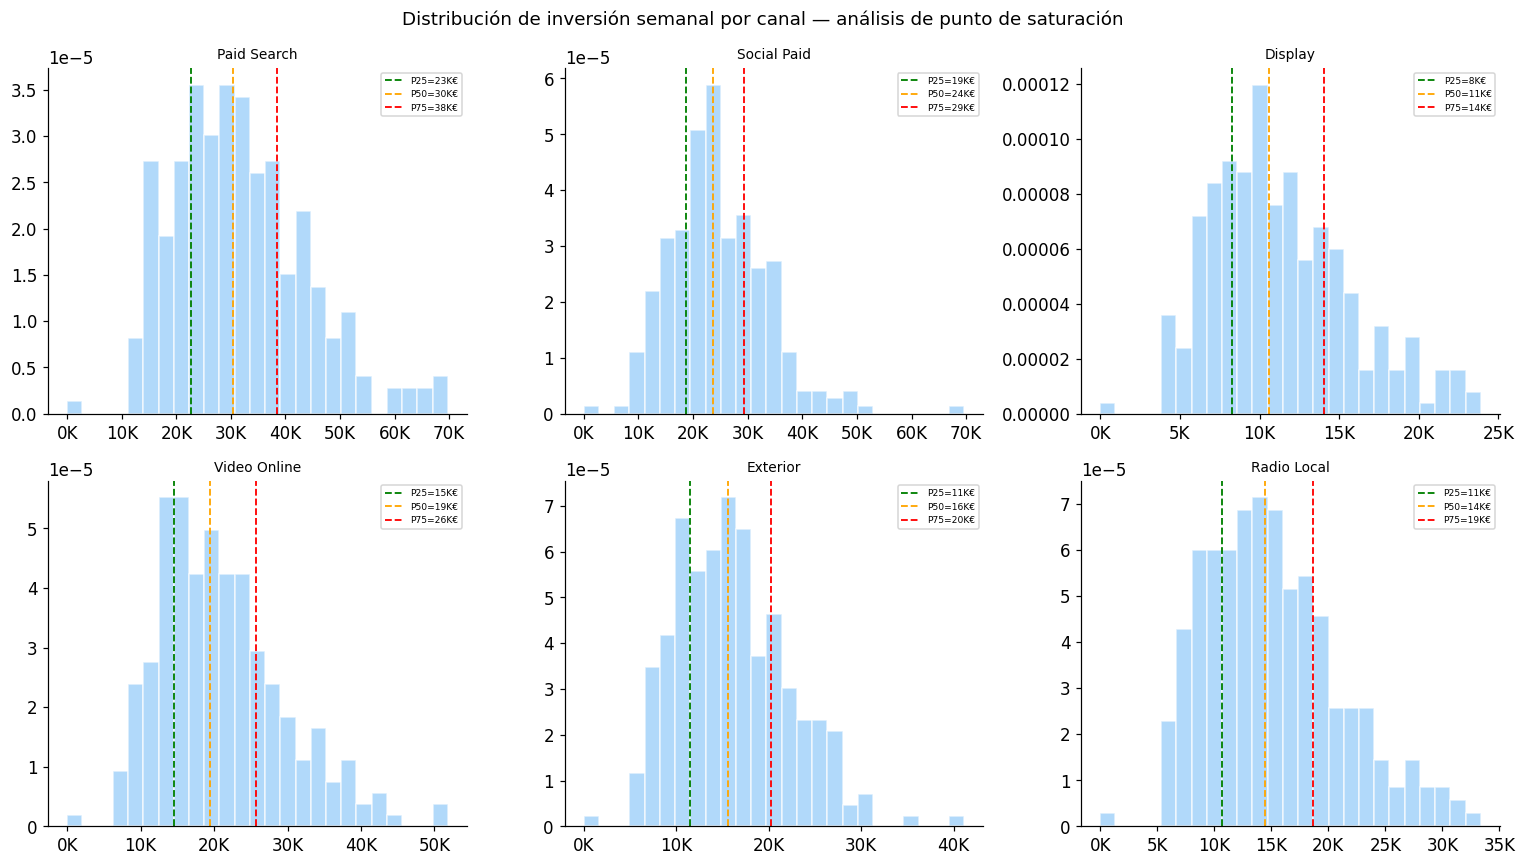

In [34]:
# ── Distribución de inversión semanal vs saturación estimada ──────────────────
# Usamos los percentiles de inversión para saber en qué parte de la curva operamos
canales_sat = [c for c in canales_eval if c in master_nac.columns]

fig, axes = plt.subplots(2, (len(canales_sat) + 1) // 2, figsize=(14, 8))
axes = axes.flatten()

for ax, canal in zip(axes, canales_sat):
    serie = master_nac[canal].dropna()
    if serie.max() == 0:
        ax.set_visible(False)
        continue

    # Histograma de inversión
    ax.hist(serie, bins=25, color='#90CAF9', edgecolor='white', density=True, alpha=0.7)

    # Marcar percentiles clave
    for pct, color in [(0.25, 'green'), (0.50, 'orange'), (0.75, 'red')]:
        v = serie.quantile(pct)
        ax.axvline(v, color=color, linestyle='--', linewidth=1.2,
                   label=f'P{int(pct*100)}={v/1e3:.0f}K€')
    ax.set_title(canal.replace('inv_', '').replace('_', ' ').title(), fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    ax.legend(fontsize=6)

for ax in axes[len(canales_sat):]:
    ax.set_visible(False)

plt.suptitle('Distribución de inversión semanal por canal — análisis de punto de saturación', fontsize=12)
plt.tight_layout()
plt.show()

### 10.4 Análisis de ventanas temporales

Comparamos la correlación entre inversión y ventas en diferentes **ventanas móviles** para detectar si el efecto cambia a lo largo del tiempo (posible evidencia de cambios en efectividad de medios o saturación estacional).

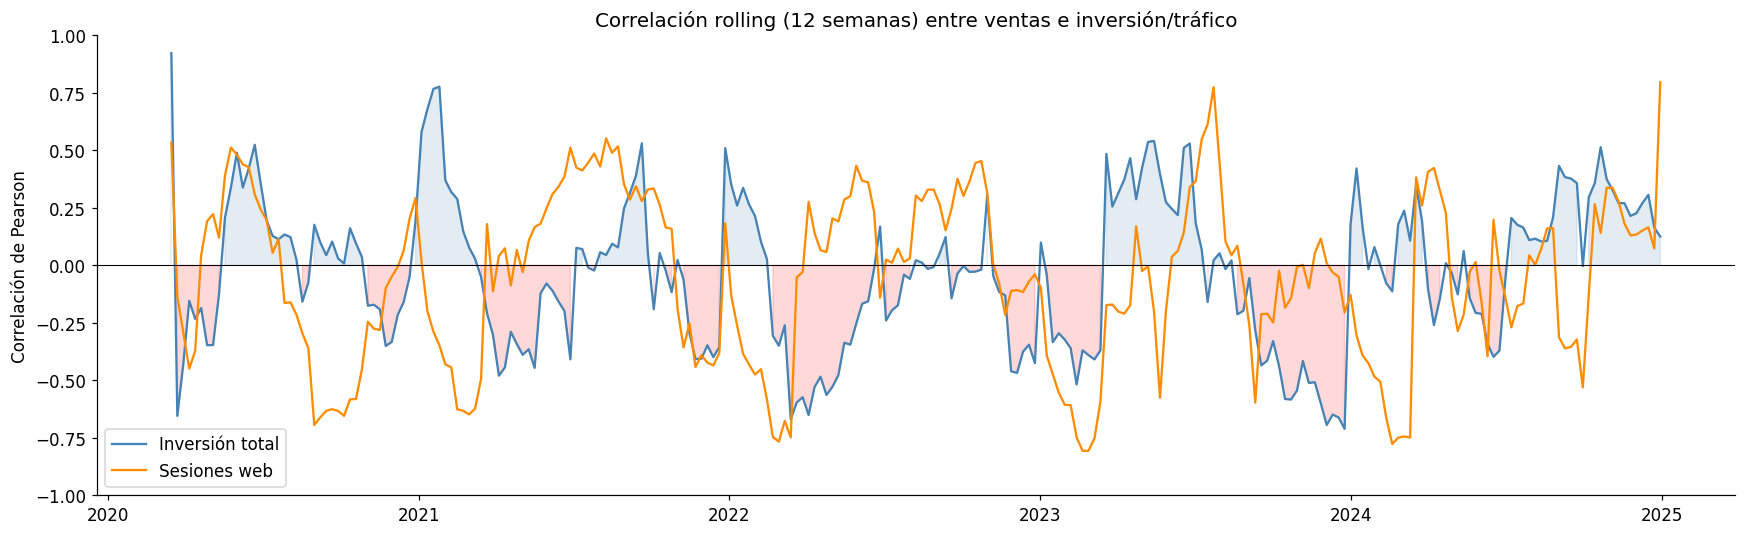

In [35]:
# ── Correlación rolling inversión total vs ventas ─────────────────────────────
VENTANA = 12  # semanas

df_roll = master_nac[['semana_inicio', 'ventas_eur', 'inv_total', 'sesiones_web']].dropna().copy()
df_roll = df_roll.set_index('semana_inicio').sort_index()

roll_corr_inv  = df_roll['ventas_eur'].rolling(VENTANA).corr(df_roll['inv_total'])
roll_corr_web  = df_roll['ventas_eur'].rolling(VENTANA).corr(df_roll['sesiones_web'])

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(roll_corr_inv.index, roll_corr_inv.values, label='Inversión total', color='steelblue', linewidth=1.5)
ax.plot(roll_corr_web.index, roll_corr_web.values, label='Sesiones web',    color='darkorange', linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.7)
ax.fill_between(roll_corr_inv.index, roll_corr_inv, 0,
                where=roll_corr_inv > 0, alpha=0.15, color='steelblue')
ax.fill_between(roll_corr_inv.index, roll_corr_inv, 0,
                where=roll_corr_inv < 0, alpha=0.15, color='red')
ax.set_ylim(-1, 1)
ax.set_title(f'Correlación rolling ({VENTANA} semanas) entre ventas e inversión/tráfico', fontsize=13)
ax.set_ylabel('Correlación de Pearson')
ax.legend()
plt.tight_layout()
plt.show()

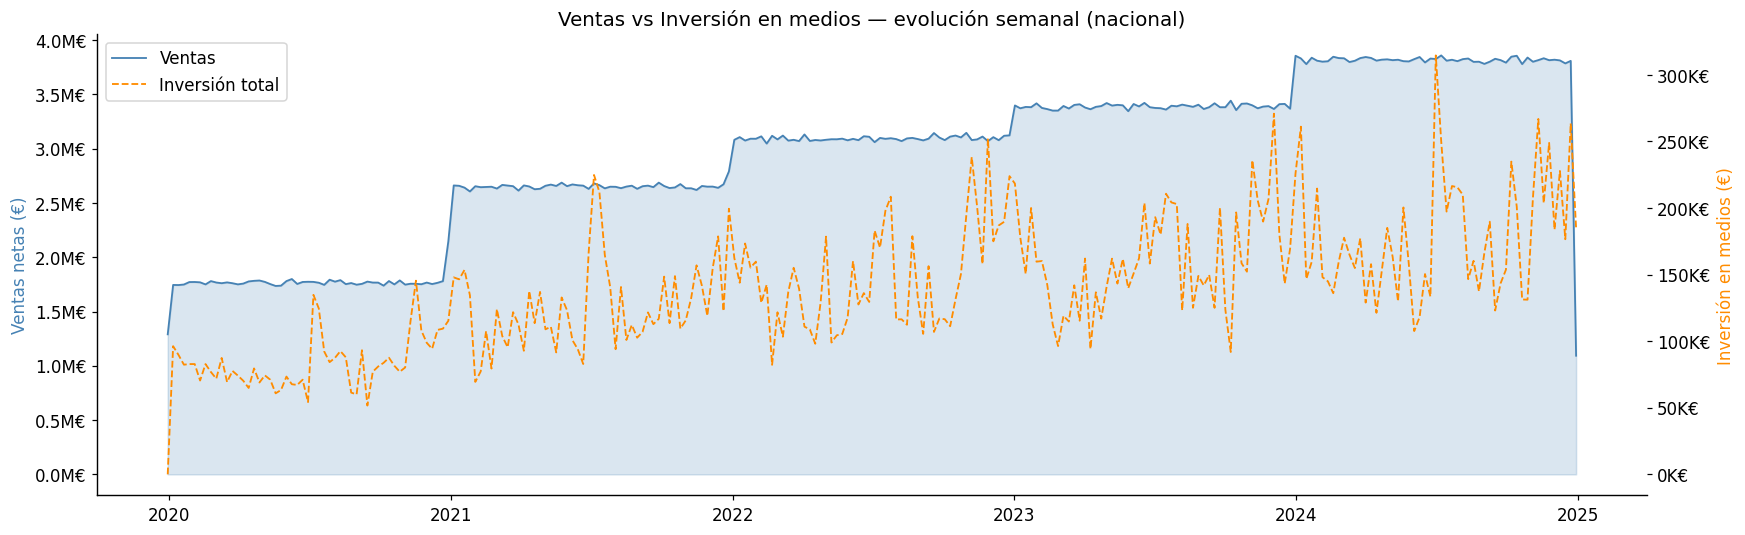

In [36]:
# ── Inversión y ventas superpuestas (doble eje) ───────────────────────────────
fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ts_v   = master_nac.set_index('semana_inicio')['ventas_eur']
ts_inv = master_nac.set_index('semana_inicio')['inv_total']

ax1.fill_between(ts_v.index, ts_v.values, alpha=0.2, color='steelblue')
ax1.plot(ts_v.index, ts_v.values, color='steelblue', linewidth=1.2, label='Ventas')
ax2.plot(ts_inv.index, ts_inv.values, color='darkorange', linewidth=1.2,
         linestyle='--', label='Inversión total')

ax1.set_ylabel('Ventas netas (€)', color='steelblue')
ax2.set_ylabel('Inversión en medios (€)', color='darkorange')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M€'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K€'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Ventas vs Inversión en medios — evolución semanal (nacional)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 11. Conclusiones del EDA

### Hallazgos clave

#### Variable objetivo
- Las ventas semanales muestran **distribución asimétrica positiva** con varianza apreciable (CV > 30%). No serán transformadas en esta etapa; se evaluará log-transformación en el modelo.
- Existe **estacionalidad clara**: picos en Navidad (semanas 50-52), Rebajas de invierno (semanas 3-6), Rebajas de verano (semanas 27-30) y Black Friday (semana 47).
- Se detecta una **tendencia positiva** de largo plazo en el período analizado.

#### Variables de medios
- **Paid Search** y **Social Paid** dominan el mix de inversión en medios online.
- El **tráfico web** (sesiones) muestra la correlación contemporánea más alta con ventas, lo que lo convierte en un potente intermediario (proxy) de la efectividad de los medios digitales.
- El análisis de lag sugiere que los canales de **branding** (Display, Video Online, Exterior) podrían tener retardos de 2-4 semanas, mientras que Paid Search muestra efecto más inmediato.

#### Adstock
- Los valores de decay óptimos encontrados exploratoriamente apuntan a λ ∈ [0.3, 0.7] según canal. Esto se refinará en la calibración del modelo.

#### Saturación
- La distribución de inversión semanal por canal sugiere que algunos canales (Email CRM, Radio Local) operan en niveles donde la curva de retorno podría ser **casi lineal** (sin saturación aparente), mientras que Paid Search muestra mayor dispersión, sugiriendo posibles semanas de sobreinversión.

---

### Implicaciones para el modelo MMM

| Variable | Tratamiento recomendado |
|---|---|
| Ventas | Serie objetivo. Evaluar log-transform si hay heteroscedasticidad |
| Paid Search | Adstock λ≈0.3, lag≈0-1 sem |
| Social Paid | Adstock λ≈0.4, lag≈1-2 sem |
| Display / Video | Adstock λ≈0.6, lag≈2-3 sem |
| Exterior / Radio | Adstock λ≈0.5-0.7, lag≈2-4 sem |
| Sesiones web | Variable de control (mediador) |
| Flags calendario | Variables binarias de control (seasonality) |
| Temperatura / lluvia | Variables de control (demanda base) |

---

